# Introduction  

**CICIDS2017 dataset**
- IDS(침입탐지시스템) 평가용 네트워크 트래픽 데이터셋

In [1]:
# Importing the relevant libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy import stats

**전처리와 분석에 필요한 패키지 호출**
- `numpy`, `pandas` : 데이터 처리
- `matplotlib` , `seaborn` : 시각화
- `sklearn` : 랜덤포레스트, train/test split, cv, 분류 리포트
- `scipy.stats` : 통계 검정

# Helper Functions

**재사용 함수 미리 정의**

In [ ]:
# 1. Get numerical and categorical features (df, target_col='Attack Type') -> numerical features; categorical features
def get_feature_types(df, target_col='Attack Type'):

    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    if target_col in numeric_features:
        numeric_features.remove(target_col)
    if target_col in categorical_features:
        categorical_features.remove(target_col)

    return numeric_features, categorical_features

**`get_feature_types(df, target_col='Attack Type')`**

- 데이터 프레임에서 **수치형/범주형 변수** 자동으로 나누는 함수
- 필요한 이유
    - 상관 관계, 이상치, 통계 검정 : **수치형 변수만을 대상**으로 하므로 함수 필요

In [ ]:
# 2. Correlation analysis (df, numeric_features) -> list of tuples with highly correlaed features
def correlation_analysis(df, numeric_features, threshold=0.85):

    corr_matrix = df[numeric_features].corr()

    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    threshold = threshold
    high_corr = np.where(np.abs(corr_matrix) > threshold)
    high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
                 for x, y in zip(*high_corr) if x != y and x < y]

    return high_corr

**`correlation_analysis(df, numeric_features, threshold=0.85)`**

- 수치형 변수들 사이의 상관 관계 분석 후 **상관계수가 높은 변수쌍** 찾기
- 필요한 이유
    - 상관 관계가 너무 높으면 사실상 같은 정보를 중복해서 담을 확률 상승
    - 모델 학습에 불필요 or 다중공산성 문제 발생

In [ ]:
# 3. Variance analysis (df, numeric_features, target_col='Attack Type') – Levene -> dict with results
def analyze_variance_homogeneity(df, numeric_features, target_col='Attack Type'): 
    
    results_levene = {}  
    
    for feature in numeric_features:  
 
        groups = [group[feature].dropna().values for name, group in df.groupby(target_col)   
                  if not group[feature].dropna().empty]  
        
        groups = [group for group in groups if len(group) > 0 and np.any(group != 0) and np.var(group) > 0]  

        if len(groups) < 2:  
            print(f"Not enough valid groups to perform Levene's test for feature: {feature}")  
            continue 

        stat_levene, p_value_levene = stats.levene(*groups)  
        results_levene[feature] = {'Statistic': stat_levene, 'p-value': p_value_levene}  

    return results_levene

**`analyze_variance_homogeneity(...)`**

- :Levene 검정 이용 -> **공격 클래스들 간 feature의 분산이 같은지** 체크
- 필요한 이유
    - 나중에 어떤 통계 검정을 쓸지 결정
    - ANOVA의 경우 분산 동질성을 가정하는데 만약 그 가정이 깨진다면 다른 검정 쓰기

In [ ]:
# 4. Feature importance analysis (df, numeric_features, target_col='Attack Type') – Kruskal-Wallis -> df with H-statistics and p-values
def analyze_feature_importance(df, numeric_features, target_col='Attack Type'):

    h_scores = {}  
    
    for feature in numeric_features:  
        groups = [group[feature].dropna().values for name, group in df.groupby(target_col)]  
        h_stat, p_val = stats.kruskal(*groups)  
        h_scores[feature] = {'H-statistic': h_stat, 'p-value': p_val}  

    h_scores_df = pd.DataFrame.from_dict(h_scores, orient='index')  
    h_scores_df = h_scores_df.sort_values('H-statistic', ascending=False)  
 
    plt.figure(figsize=(18, 10))  
    plt.bar(range(len(h_scores_df)), h_scores_df['H-statistic'], color='skyblue')  
    plt.xticks(range(len(h_scores_df)), h_scores_df.index, rotation=90)  
    plt.title('Feature Importance based on H-statistic (Kruskal-Wallis Test)')  
    plt.xlabel('Features')  
    plt.ylabel('H-statistic')  
    plt.tight_layout()  
    plt.show()  

    return h_scores_df

**`analyze_feature_importance(...)`**

- Kruskal-Wallis 검정 이용 -> **각 feature가 공격 유형에 따라 유의미하게 값 차이를 보이는지** 확인하는 함수
- 필요한 이유
    - 정규분포가 아니고 분산 동질성이 애매하면 비모수 검정이 더 적절할 수 있음
    - 이럴 때 **feature 중요도**를 통계적으로 판단하는 용도

In [ ]:
# 5. Feature importance analysis(df, numeric_features, target_col='Attack Type') – Tree Model -> df with features ordered by importance; confusion matrix; labels; cv_scores
def analyze_feature_importance_rf(df, numeric_features, target_col='Attack Type'):

    hyperparameters = {
        'n_estimators': 150, 
        'max_depth': 30,   
        'random_state': 42,  
        'n_jobs': -1          
    }

    X = df[numeric_features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=hyperparameters['random_state'], stratify=y)

    rf = RandomForestClassifier(**hyperparameters)

    rf.fit(X_train, y_train)

    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
    print(f'Cross-Validation Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
    
    y_pred = rf.predict(X_test)

    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': numeric_features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    rf_labels = rf.classes_
    cm = confusion_matrix(y_test, y_pred)

    report = classification_report(y_test, y_pred, target_names=rf_labels)
    print("\nClassification Report:\n")
    print(report, end='\n\n')

    plt.figure(figsize=(18, 12))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.title('Feature Importance from Random Forest')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return feature_importance_df, cm, rf_labels, cv_scores

**`analyze_feature_importance_rf(...)`**

- 랜덤포레스트 분류기 학습 -> **각 feature 중요도** 계산
- 추가로 하는 일
    - confusion matrix
    - classification report
    - cross validation score
- 필요한 이유
    - 통계 검정 기반 중요도와 트리모델 기반 중요도를 비교

In [ ]:
# 6. Calculation of the percentage of outliers for each feature (df) – IQR -> dict with outliers percentage
def calculate_outliers_percentage(df):

    outlier_percentages = {}  

    for column in df.columns:
        Q1 = df[column].quantile(0.25)  
        Q3 = df[column].quantile(0.75) 
        lower_bound = Q1 - 1.5 * IQR  
        upper_bound = Q3 + 1.5 * IQR 

        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        outlier_percentage = len(outliers) / len(df) * 100

        outlier_percentages[column] = outlier_percentage

    return outlier_percentages


**`calculate_outliers_percentage(df)`**

- *IQR 방식*으로 **각 컬럼의 이상치 비율을 계산**하는 함수
- 필요한 이유
    - 이 데이터가 이상치가 많은지 확인 -> 스케일링, 로버스트한 모델, 비모수 검정 같은 선택 정당화 가능

# 1. Initial Exploration

## 1.1. Loading the Dataset

In [ ]:
dfs = []

for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        dfs.append(pd.read_csv(os.path.join(dirname, filename)))

In [ ]:
# Data dimensions of each individual dataset
for i, data in enumerate(dfs, start=1):
    rows, cols = data.shape
    print(f'df{i} -> {rows} rows, {cols} columns')

df1 -> 286467 rows, 79 columns
df2 -> 170366 rows, 79 columns
df3 -> 445909 rows, 79 columns
df4 -> 225745 rows, 79 columns
df5 -> 529918 rows, 79 columns
df6 -> 191033 rows, 79 columns
df7 -> 288602 rows, 79 columns
df8 -> 692703 rows, 79 columns


**각 개별 데이터프레임의 크기 출력**

- 각 파일의 행/열 수:
    - df1: 286,467행, 79열
    - df2: 170,366행, 79열
    - df3: 445,909행, 79열
    - df4: 225,745행, 79열
    - df5: 529,918행, 79열
    - df6: 191,033행, 79열
    - df7: 288,602행, 79열
    - df8: 692,703행, 79열

- 총 8개 파일, 모두 컬럼 수는 79개로 동일
- **행 기준으로 합치기 적절한 구조**

## 1.2. Merging the DataFrames

**분리된 파일들을 하나로 합침**

In [10]:
# Concatenate all DataFrames into a single DataFrame
data = pd.concat(dfs, axis=0, ignore_index=True)

# Deleting DataFrames after merging
for df in dfs: del df

**8개의 파일을 하나의 큰 데이터프레임 `data`로 합침**
- 기존 개별 df 들은 메모리에서 삭제

## 1.3. Data Overview

**병합한 전체 데이터의 형태 보기**

In [11]:
# Display the first few rows
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**네트워크 흐름(flow) 단위의 통계값들이 feature**로 들어가 있음

In [12]:
# Display 10 random rows
data.sample(n=10, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,443,20829,1,1,0,0,0,0,0.000000,0.000000,...,20,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN
946912,80,1413228,3,5,26,11601,20,0,8.666667,10.263203,...,20,0.000000,0.000000,0,0,0.0,0.00000,0,0,DDoS
2216843,80,99951883,9,7,317,11595,317,0,35.222222,105.666667,...,32,999.000000,0.000000,999,999,99900000.0,0.00000,99900000,99900000,DoS Hulk
699389,80,12984169,9,11,10081,3626,3445,0,1120.111111,1452.563720,...,20,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN
1170268,80,116017190,16,14,520,802,436,0,32.500000,107.610408,...,20,30442.181818,22653.805702,98745,23484,9998871.0,16434.76758,10012179,9950666,BENIGN
800686,53,226,2,2,46,46,23,23,23.000000,0.000000,...,32,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN
1434488,53,63936,1,1,49,161,49,49,49.000000,0.000000,...,32,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN
1968368,443,63405,5,4,121,3110,121,0,24.200000,54.112845,...,32,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN
934343,443,6310806,54,94,2958,170879,517,0,54.777778,142.380260,...,32,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN
693547,53,193,2,2,68,100,34,34,34.000000,0.000000,...,32,0.000000,0.000000,0,0,0.0,0.00000,0,0,BENIGN


In [13]:
# Get dataset dimensions
print(f"Dataset Dimensions: {data.shape}")

Dataset Dimensions: (2830743, 79)


**매우 큰 규모의 데이터셋**

- 총 행 수: 2,830,743
- 총 컬럼 수: 79

In [14]:
# Display data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

**칼럼별 자료형과 결측 여부 확인**

- 대부분 수치형
- 범주형은 `Label`뿐..
    - feature 대부분이 연속형/수치형이므로 추후 **통계 처리나 모델 입력에 적합**

In [15]:
# Checking for missing values
missing_values = data.isna().sum()
missing_percentage = (missing_values / len(data)) * 100

# Printing columns with missing values
for column, count in missing_values.items():
    if count != 0:
        print(f"Column '{column}' has {count} missing values, which is {missing_percentage[column]:.2f}% of the total")

Column 'Flow Bytes/s' has 1358 missing values, which is 0.05% of the total


**결측치 개수 확인**
- `Flow Bytes/s` 에만 `1358`개의 결측치 : 전체 대비 약 `0.05%`
- 결측치는 아주 작은 편
    - 하지만 완전히 무시할 정도는 아님

# 2. Data Cleaning

In [ ]:
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

**컬럼명의 앞뒤 공백 제거**

- `' Flow Duration '`
    - 공백이 섞여 있으면 나중에 컬럼 참조에서 오류가 날 수 있음
    - 미리 정리

## 2.1. Duplicates and Infinite

**중복과 무한대 처리**

In [17]:
# Checking and counting duplicates
duplicates = data.duplicated()
duplicate_count = duplicates.sum()

# Output results
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 308381


**중복행 개수 확인**

- `308381`개의 중복행
- 중복이 **꽤 많음** -> **제거**하는 편이 데이터 품질 측면에서 중요하다 판단
> 중복 제거가 일반적으로 안전하고 유익

In [18]:
# Removal of duplicates
data = data.drop_duplicates(keep='first')
del duplicates
data.shape

(2522362, 79)

**중복행 제거**

- 중복 제거 전 `2,830,743`행 -> `2,522,362`
- 중복행이 약 30만 개 이상 제거

In [19]:
# Identify columns with identical data
identical_columns = {}
columns = data.columns
list_control = columns.copy().tolist()

# Compare each pair of columns
for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if data[col1].equals(data[col2]):
                if (col1 not in identical_columns) and (col1 in list_control):
                    identical_columns[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in identical_columns) and (col1 in list_control):
                    identical_columns[col1].append(col2)
                    list_control.remove(col2)

# Print the result
if identical_columns:
    print("Identical columns found:")
    for key, value in identical_columns.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']
'Fwd Header Length' is identical to ['Fwd Header Length.1']


**행 뿐만 아니라 컬럼 중복 여부 확인**

- `Total Fwd Packets` = `Subflow Fwd Packets`
- `Total Backward Packets` = `Subflow Bwd Packets`
- `Fwd Header Length` = `Fwd Header Length.1` 등등

- 서로 다른 이름이지만 실제 값이 완전히 같은 컬럼들
- **중복 정보 정리 대상**

In [20]:
# Removing the columns with duplicated values
for key, value in identical_columns.items():
    data.drop(columns=value, inplace=True)

**중복 컬럼 삭제**

- 완전히 같은 정보를 담는 열 삭제
- `feature redundancy` 줄임

In [21]:
print(data.columns)
data.shape

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

(2522362, 67)

In [22]:
# Checking for infinite values
num_columns = data.select_dtypes(include = np.number).columns
has_infinite = np.isinf(data[num_columns]).sum()
print(has_infinite[has_infinite > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


**무한대값(`inf`) 존재 여부 확인**

- `Flow Bytes/s`: 1211개
- `Flow Packets/s`: 1564개

- 일부 계산형 지표에서 분모가 0에 가까워지면서 무한대가 발생
- **모델에 넣으면 문제 발생..**

> 무한대값 제거가 일반적으로 적절

In [23]:
# Treating infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)

**무한대 값을 `NaN`으로 변환**

- 바로 제거 X
- 먼저 결측치로 바꾼 후 결칙치 처리 로직에서 함께 다루기

## 2.1. Missing Values

In [24]:
# Attack counts
attack_counts = data['Label'].value_counts().reset_index()
attack_counts.columns = ['Attack Type', 'Number of Occurrences']

# Duplicating the df and dropping rows with missing values
data_no_na = data.dropna()

# Counting the total number of occurrences of each attack after dropping
occurrences_nonull = data_no_na['Label'].value_counts().reset_index()
occurrences_nonull.columns = ['Attack Type', 'Occurrences w/o Null Rows']

# Merging the DataFrames
attack_counts = attack_counts.merge(occurrences_nonull, on='Attack Type', how='left')

# Calculating the difference
attack_counts['Abs Difference'] = attack_counts['Number of Occurrences'] - attack_counts['Occurrences w/o Null Rows']
attack_counts['Difference %'] = ((attack_counts['Abs Difference'] * 100) / attack_counts['Number of Occurrences']).round(2)

# Visualization
attack_counts

,Attack Type,Number of Occurrences,Occurrences w/o Null Rows,Abs Difference,Difference %
0,BENIGN,2096484,2095057,1427,0.07
1,DoS Hulk,172849,172846,3,0.00
2,DDoS,128016,128014,2,0.00
3,PortScan,90819,90694,125,0.14
4,DoS GoldenEye,10286,10286,0,0.00
5,FTP-Patator,5933,5931,2,0.03
6,DoS slowloris,5385,5385,0,0.00
7,DoS Slowhttptest,5228,5228,0,0.00
8,SSH-Patator,3219,3219,0,0.00
9,Bot,1953,1948,5,0.26


**결측치 제거 전후로 각 공격 라벨의 개수를 비교**

- 결측치 행을 제거했을 때 어떤 공격 클래스가 얼마나 줄어드는지 확인
- **결측치 제거가 특정 클래스에 치명적 영향을 주는지 확인**

In [25]:
# Cleaning up
del data_no_na

# Evaluating percentage of missing values per column
threshold = 10
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Filter columns with missing values over the threshold
high_missing_cols = missing_percentage[missing_percentage > threshold]

# Print columns with high missing percentages
if len(high_missing_cols) > 0:
    print(f'The following columns have over {threshold}% of missing values:')
    print(high_missing_cols)
else:
    print('There are no columns with missing values greater than the threshold')

There are no columns with missing values greater than the threshold


**컬럼별 결측 비율이 10% 넘는 경우가 있는지 확인**

- 10% 넘는 컬럼 없음
- 결측치가 특정 컬럼에 몰려 있지 않음
- **컬럼 자체를 통째로 버릴 필요는 없다**
- **결측치가 한 컬럼에 집중되지 않았으므로 행 단위 제거도 큰 문제 없다**

In [26]:
row_missing_percentage = (data.isna().sum(axis=1) / data.shape[1]) * 100
print(row_missing_percentage.describe())

missing_rows = data.isna().any(axis=1).sum()
print(f'\nTotal rows with missing values: {missing_rows}')

count    2.522362e+06
mean     1.850907e-03
std      7.430795e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.985075e+00
dtype: float64

Total rows with missing values: 1564


**행별 결측 비율 확인**

- 총 결측 포함 행 수: `1564`
- 전체 데이터(250만 행 이상) 대비 1564행 제거 -> 영향 매우 작음..

In [27]:
# Dropping missing values
data = data.dropna()
print(f'Dataset shape after row-wise removal: {data.shape}')

Dataset shape after row-wise removal: (2520798, 67)


**dropna() 수행**

- Dataset shape after row-wise removal: (2520798, 67)

해석

결측치 있는 행을 제거한 뒤 데이터 크기를 다시 확인한 거야.
컬럼 수가 줄어든 건 앞 단계에서 중복 컬럼 제거가 이미 진행되었기 때문

## 2.2. Data-Driven Feature Selection

**선행 연구와 분석 결과 고려 -> 결측치 행 제거**

In [ ]:
only_unique_cols = []
for col in data.columns:
    if len(data[col].unique()) == 1:
        only_unique_cols.append(col)
        print(col)

print(f'\nThe number of columns with only one unique values is: {len(only_unique_cols)}')

Bwd PSH Flags

The number of columns with only one unique values is: 1


**값이 하나밖에 없는 컬럼 찾기**

- `Bwd PSH Flags`
    - 모든 행에서 값이 동일하
    - 분류에 아무 도움 X

In [29]:
# Dropping the columns with only one unique value
data.drop(only_unique_cols, axis=1, inplace=True)
del only_unique_cols

**단일값 컬럼 -> 보통 제거해도 ㄱㅊ**

In [30]:
# Checking the new shape after cleaning
data.shape

(2520798, 66)

**제거 후 shape**

- `(2520798, 66)` : 컬럼 하나 제거된 상태

## 2.3. Grouping/ Removing Attack Types


**공격 유형 그룹화/제거 설명**

- 라벨 종류가 너무 세분화되어 있고 클래스 불균형도 심함
- *유사한 공격은 묶어서 더 안정적인 분류 문제로 만들자*

### 2.3.1. Grouping attack types

**공격 타입을 어떤 그룹으로 묶을지 표로 설명**

- 여러 DoS 변종을 하나의 DoS 그룹으로 묶음
- 단, **DDoS는 별도로 유지**


| **Group**                     | **Attack Type**             | **Count**  |  
|-------------------------------|-----------------------------|------------|  
| **Normal Traffic**            | BENIGN                      | 2,095,057  |  
|                               |                             | **Total: 2,095,057** |  
| **DoS Attacks**              | DoS Hulk                   | 172,846    |  
|                               | DoS GoldenEye               | 10,286     |  
|                               | DoS Slowloris               | 5,385      |  
|                               | DoS Slowhttptest            | 5,228      |
|                               |                             | **Total: 193,745** |
| **DDoS Attacks**              | DDoS                        | 128,014     |
|                               |                             | **Total: 128,014** |
| **Port Scanning**            | PortScan                    | 90,694     |  
|                               |                             | **Total: 90,694**  |  
| **Brute Force Attacks**      | FTP-Patator                 | 5,931      |  
|                               | SSH-Patator                 | 3,219      |  
|                               |                             | **Total: 9,150**   |  
| **Bots**                      | Bot                         | 1,948      |  
|                               |                             | **Total: 1,948**   |  
| **Web Attacks**              | Web Attack – Brute Force    | 1,470      |  
|                               | Web Attack – XSS            | 652        |  
|                               | Web Attack – SQL Injection   | 21         |  
|                               |                             | **Total: 2,143**   |  
| **Infiltration Attacks**     | Infiltration                | 36         |  
|                               |                             | **Total: 36**      |  
| **Miscellaneous**            | Heartbleed                  | 11         |  
|                               |                             | **Total: 11**      |

In [31]:
# Mapping the attacks to the new group
group_mapping = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'DoS GoldenEye': 'DoS',
    'FTP-Patator': 'Brute Force',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Infiltration': 'Infiltration',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Heartbleed': 'Miscellaneous'
}

# Map to new group column
data['Attack Type'] = data['Label'].map(group_mapping)

**공격 라벨 매핑**

- `BENIGN` → `Normal Traffic`
- `DoS Hulk`, `DoS GoldenEye`, `DoS slowloris` 등 → `DoS`
- `FTP-Patator`, `SSH-Patator` → `Brute Force`
- 웹 공격들 → `Web Attacks`

세분 공격명을 좀 더 큰 카테고리로 통합

In [32]:
# Checking the new values
data['Attack Type'].value_counts()

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Infiltration           36
Miscellaneous          11
Name: count, dtype: int64

**새로운 Attack Type 분포 확인**

- Normal Traffic: 2,095,057
- DoS: 193,745
- DDoS: 128,014
- Port Scanning: 90,694
- Brute Force: 9,150
- Web Attacks: 2,143
- Bots: 1,948
- Infiltration: 36
- Miscellaneous: 11

그룹화 후에도 **여전히 극단적으로 적은 클래스**가 존재

In [33]:
# Dropping the old 'Label' column
data.drop(columns='Label', inplace=True)

**기존 Label 컬럼 삭제**

- 새로운 `Attack Type`이 타깃 라벨 역할 -> 기존 라벨 필요 없음

### 2.3.2. Removal of Attack Types

**표본 수가 너무 적은 공격 유형을 제거**

- 대상
    - `Infiltration` 36개
    - `Miscellaneous` 11개

- 이 정도로 적으면 모델이 제대로 학습하기 어렵고, 오버피팅 위험이 큼

In [34]:
# Removing rows with statistically irrelevant attack types
data.drop(data[(data['Attack Type'] == 'Infiltration') | (data['Attack Type'] == 'Miscellaneous')].index, inplace=True)

**희소 클래스 제거**

- 표본 수가 지나치게 적은 클래스 행 삭제

In [35]:
# Data shape and attack counts after removal
print(data.shape)
data['Attack Type'].value_counts()

(2520751, 66)


Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

**삭제 후 shape 및 공격 분포 확인**

- shape: `(2520751, 66)`

- 47개 행이 제거
- 타깃 클래스는 보다 **현실적인 다중분류 문제**로 정리

# 3. Exploratory Data Analysis (EDA)

## 3.1. Descriptive Statistics

**기초 통계 소제목**

In [36]:
data.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Type
1551142,62283,53121,2,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
1405688,443,1668662,6,3,611,162,517,0,101.833333,204.305082,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
640971,80,1978,2,0,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
540921,53,71990,2,2,56,172,28,28,28.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
563303,53849,999853,2,0,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
1033540,80,36013,6,0,36,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
2303872,80,98250786,6,6,397,11595,379,0,66.166667,153.284594,...,20,15896.0,0.0,15896,15896,98200000.0,0.0,98200000,98200000,DoS
1750862,53,15194583,4,4,152,530,46,30,38.000000,9.237604,...,20,49027.0,0.0,49027,49027,15100000.0,0.0,15100000,15100000,Normal Traffic
1144830,53,48978,1,1,49,91,49,49,49.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal Traffic
956600,80,266536,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS


In [37]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,...,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06
mean,8.690744e+03,1.659032e+07,1.025880e+01,1.155289e+01,6.065243e+02,1.811292e+04,2.311993e+02,1.920377e+01,6.350189e+01,7.732029e+01,...,5.997266e+00,-3.082291e+03,9.152230e+04,4.616835e+04,1.719410e+05,6.542438e+04,9.337159e+06,5.656738e+05,9.763454e+06,8.892545e+06
std,1.901294e+04,3.523140e+07,7.943824e+02,1.056905e+03,1.011595e+04,2.398149e+06,7.563122e+02,6.079887e+01,1.955512e+02,2.968824e+02,...,6.743909e+02,1.149769e+06,6.858746e+05,4.161453e+05,1.084664e+06,6.106447e+05,2.484810e+07,4.873871e+06,2.561725e+07,2.458139e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.062000e+04,2.000000e+00,2.000000e+00,6.600000e+01,1.560000e+02,4.000000e+01,2.000000e+00,3.625000e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.332968e+06,6.000000e+00,5.000000e+00,3.320000e+02,9.970000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.419280e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


**`data.describe()`**

- 각 수치형 변수의
    - 평균
    - 표준편차
    - 최소값
    - 사분위수
    - 최대값

- 일부 변수는 분산이 매우 큼
- 일부 변수는 극단값이 존재할 가능성이 높음
    - 최대값과 중앙값 차이가 크면 이상치 가능성 상승

## 3.2. Correlation Analysis

**상관 관계 분석**

- 차원축소 및 feature 정리 고민

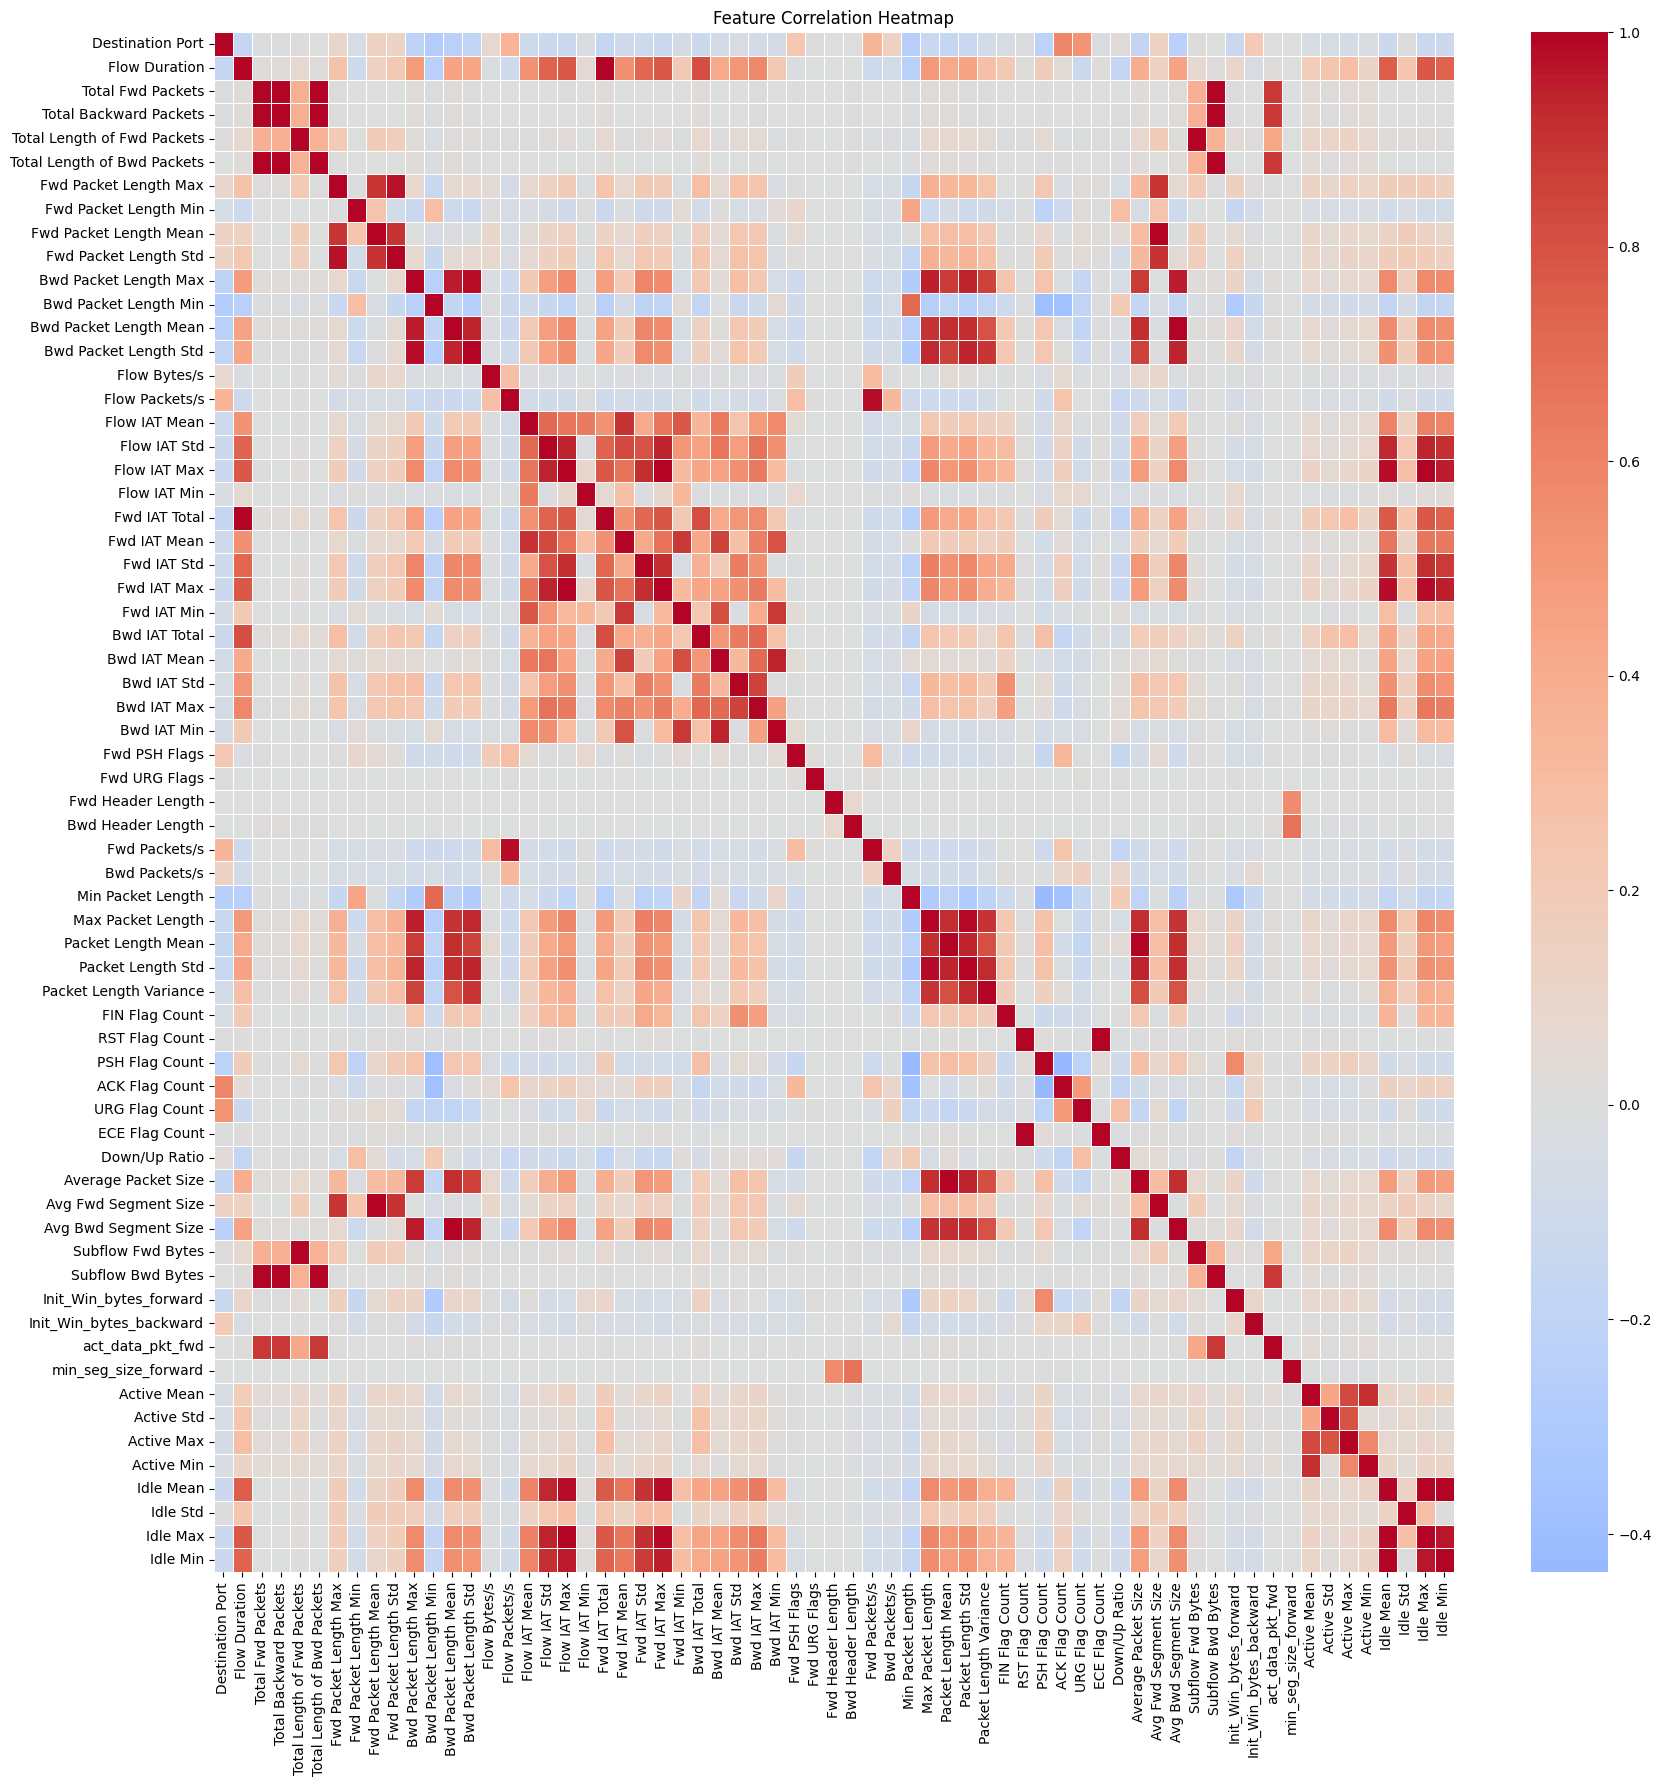

In [38]:
# Correlation Analysis:
numeric_features, categorical_features = get_feature_types(data)
high_corr = correlation_analysis(data, numeric_features)

In [39]:
# Printing the pairs with high correlation and isolating the near/perfect multicollinearity
high_multicollinearity = []
for item in high_corr:
    print(f'{item[0]} has a high correlation with {item[1]}: {item[2].round(4)}')
    if item[2] >= 0.95:
        high_multicollinearity.append(item)

Flow Duration has a high correlation with Fwd IAT Total: 0.9985
Total Fwd Packets has a high correlation with Total Backward Packets: 0.9991
Total Fwd Packets has a high correlation with Total Length of Bwd Packets: 0.997
Total Fwd Packets has a high correlation with Subflow Bwd Bytes: 0.997
Total Fwd Packets has a high correlation with act_data_pkt_fwd: 0.8874
Total Backward Packets has a high correlation with Total Length of Bwd Packets: 0.9945
Total Backward Packets has a high correlation with Subflow Bwd Bytes: 0.9944
Total Backward Packets has a high correlation with act_data_pkt_fwd: 0.8826
Total Length of Fwd Packets has a high correlation with Subflow Fwd Bytes: 1.0
Total Length of Bwd Packets has a high correlation with Subflow Bwd Bytes: 1.0
Total Length of Bwd Packets has a high correlation with act_data_pkt_fwd: 0.884
Fwd Packet Length Max has a high correlation with Fwd Packet Length Mean: 0.889
Fwd Packet Length Max has a high correlation with Fwd Packet Length Std: 0.968

**상관계수가 높은 변수쌍 출력**

- `Flow Duration` ↔ `Fwd IAT Total`: 0.9985
- `Total Fwd Packets` ↔ `Total Backward Packets`: 0.9991
등등등

- 사실상 거의 같은 정보를 담는 feature들이 많다 -> **이런 변수는 일부 제거하는 것이 합리적**

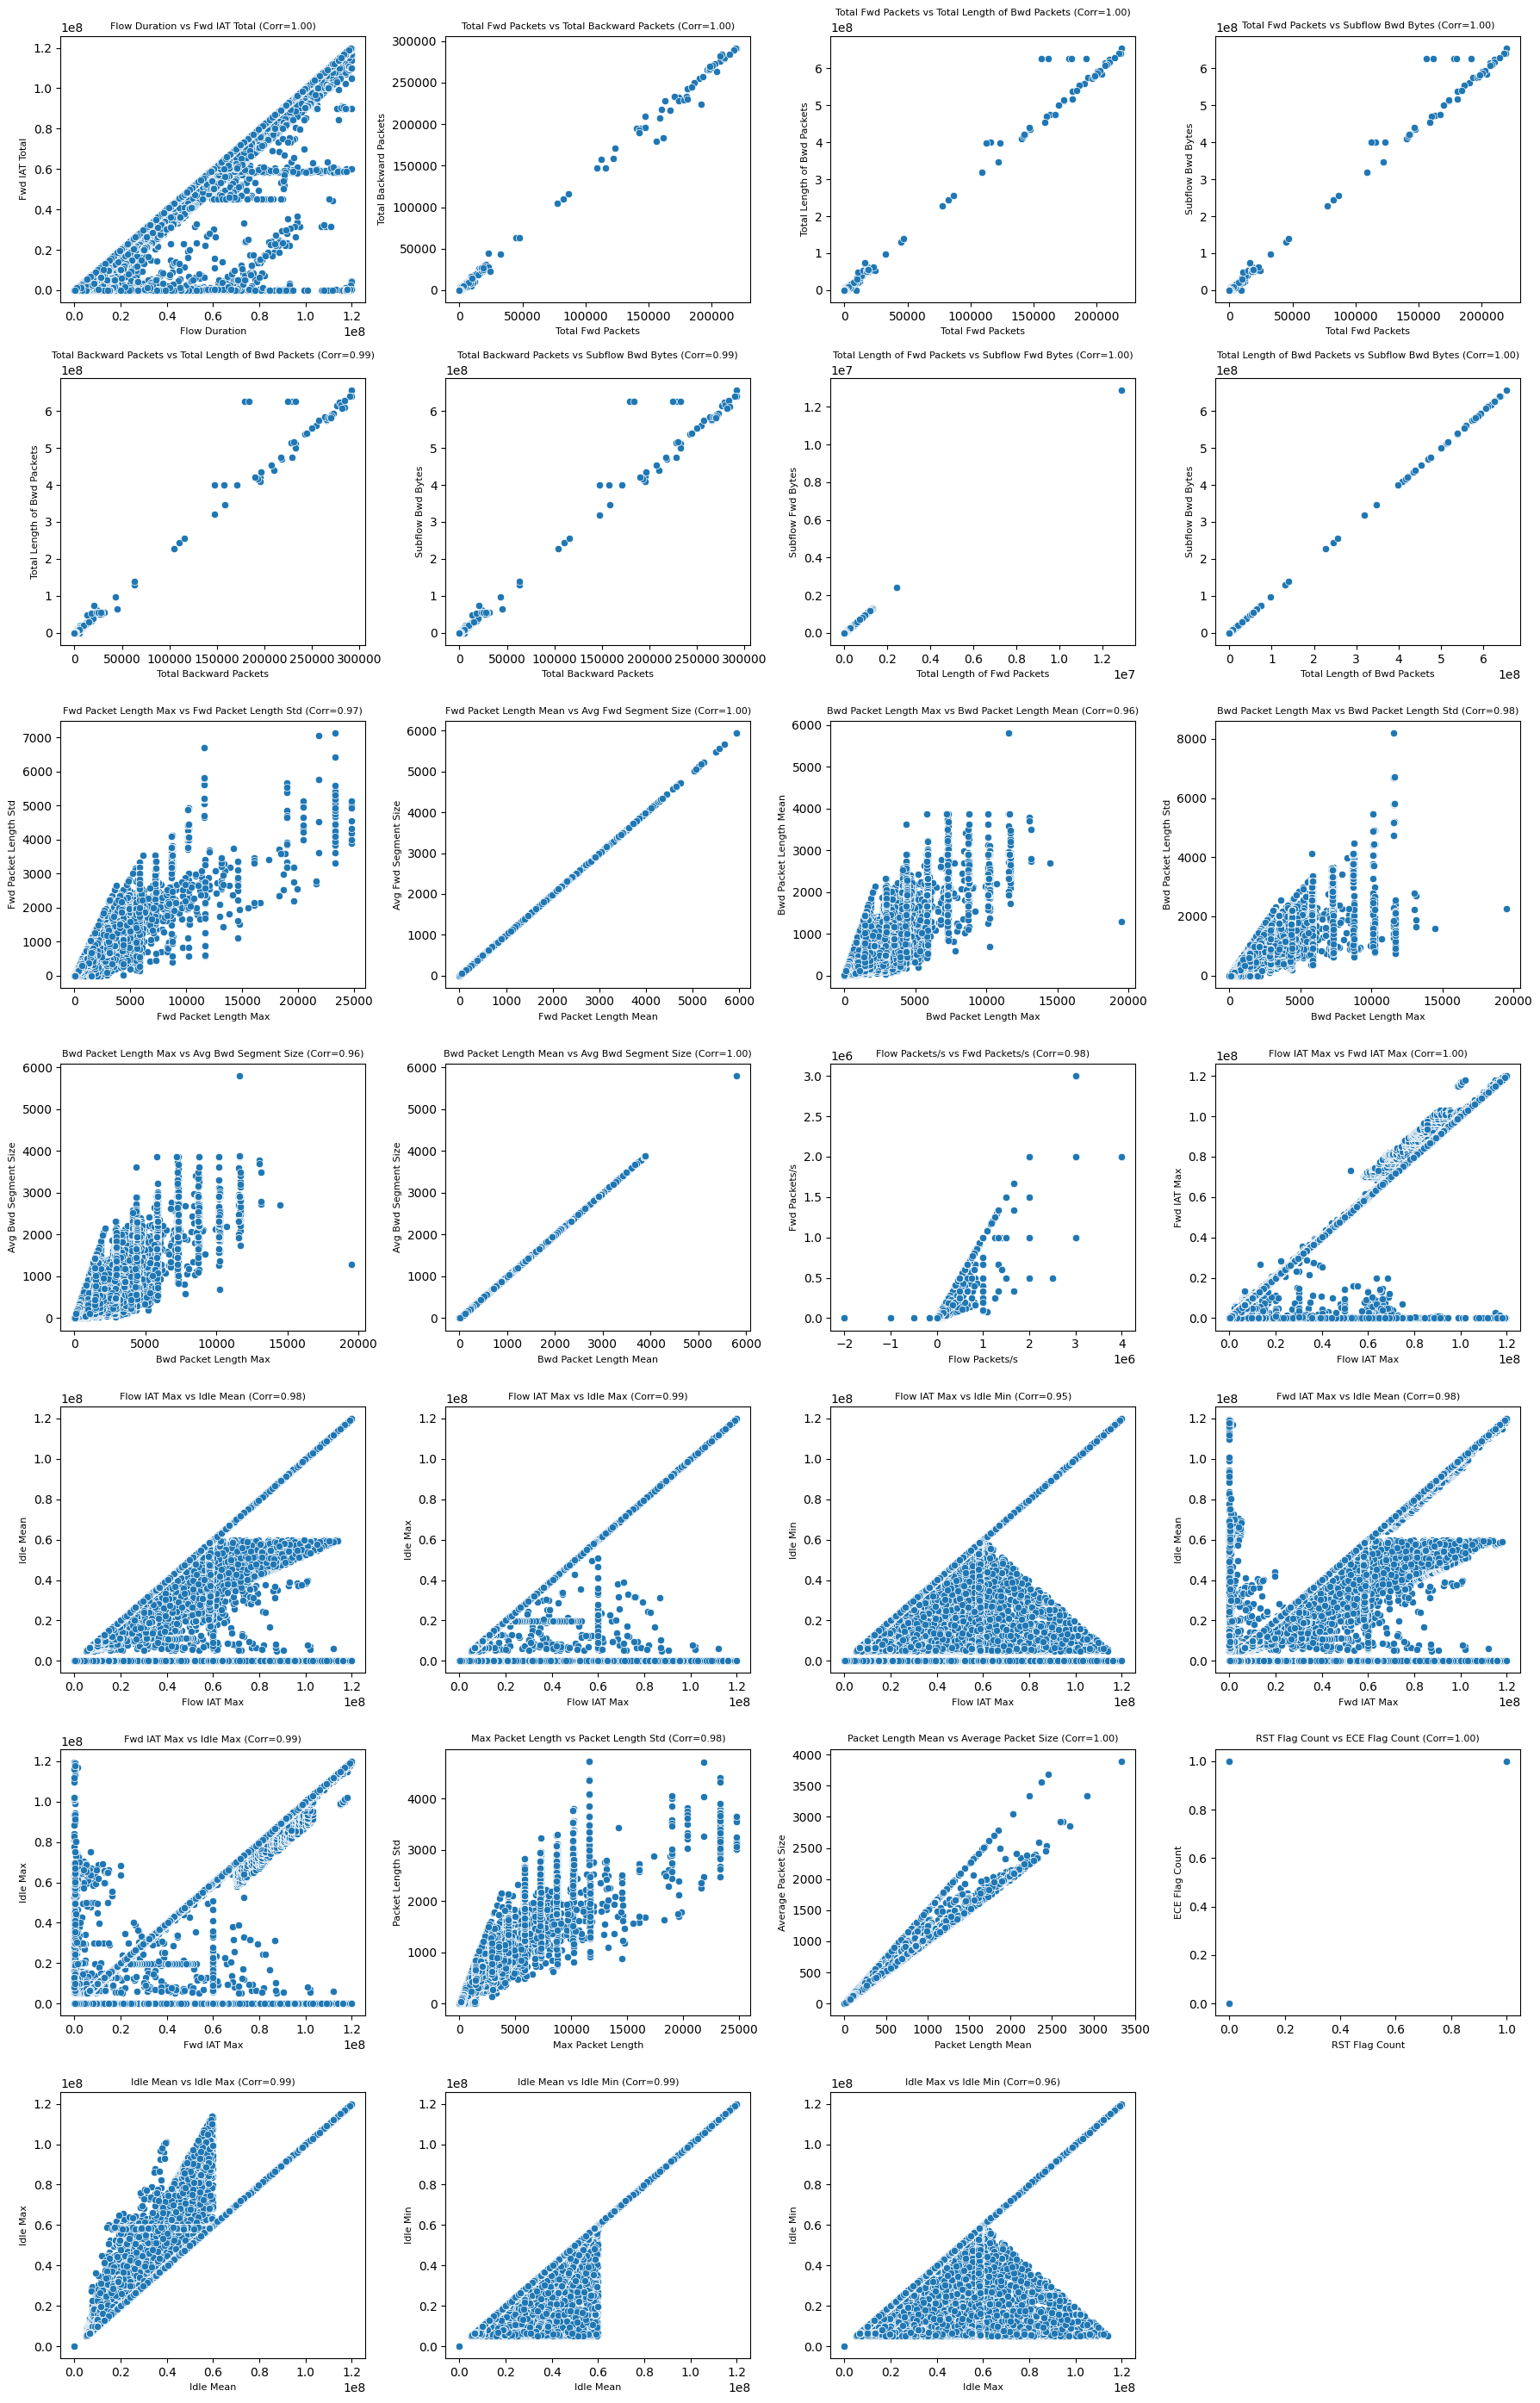

In [40]:
# Plotting the pairs with very high correlation for better visualization

n_plots = len(high_multicollinearity)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, item in enumerate(high_multicollinearity):
    feature_x = item[0]
    feature_y = item[1]
    corr_value = item[2]

    # Scatter plot
    sns.scatterplot(x=data[feature_x], y=data[feature_y], ax=axes[i])
    axes[i].set_title(f'{feature_x} vs {feature_y} (Corr={corr_value:.2f})', fontsize=8)
    axes[i].set_xlabel(feature_x, fontsize=8)
    axes[i].set_ylabel(feature_y, fontsize=8)

# Hide any unused subplots
for j in range(len(high_multicollinearity), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**매우 높은 상관쌍들을 산점도로 시각화**

- 거의 정말 직선 관계인지 확인
- 그런 것들은 변수 하나 제거해도 된당

In [41]:
# Removal of columns based on correlation analysis
selected_columns = ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']

# dropping columns with perfect/near perfect multicollinearity
data.drop(columns=selected_columns, inplace=True)

**관성이 매우 높은 컬럼 제거**

- 제거 컬럼
    - `Total Backward Packets`
    - `Total Length of Bwd Packets`
    - `Subflow Bwd Bytes`
    - `Avg Fwd Segment Size`
    - `Avg Bwd Segment Size`

- **중복성이 큰 feature를 줄여서 모델 단순화**

In [42]:
# Updating the variables and checking dataset shape
numeric_features, categorical_features = get_feature_types(data)
data.shape

(2520751, 61)

**업데이트 후 shape 확인**

- `(2520751, 61)`
- 상관이 높은 5개 컬럼이 제거

## 3.3. Outliers

**이상치 분석**

<Figure size 1500x1000 with 0 Axes>

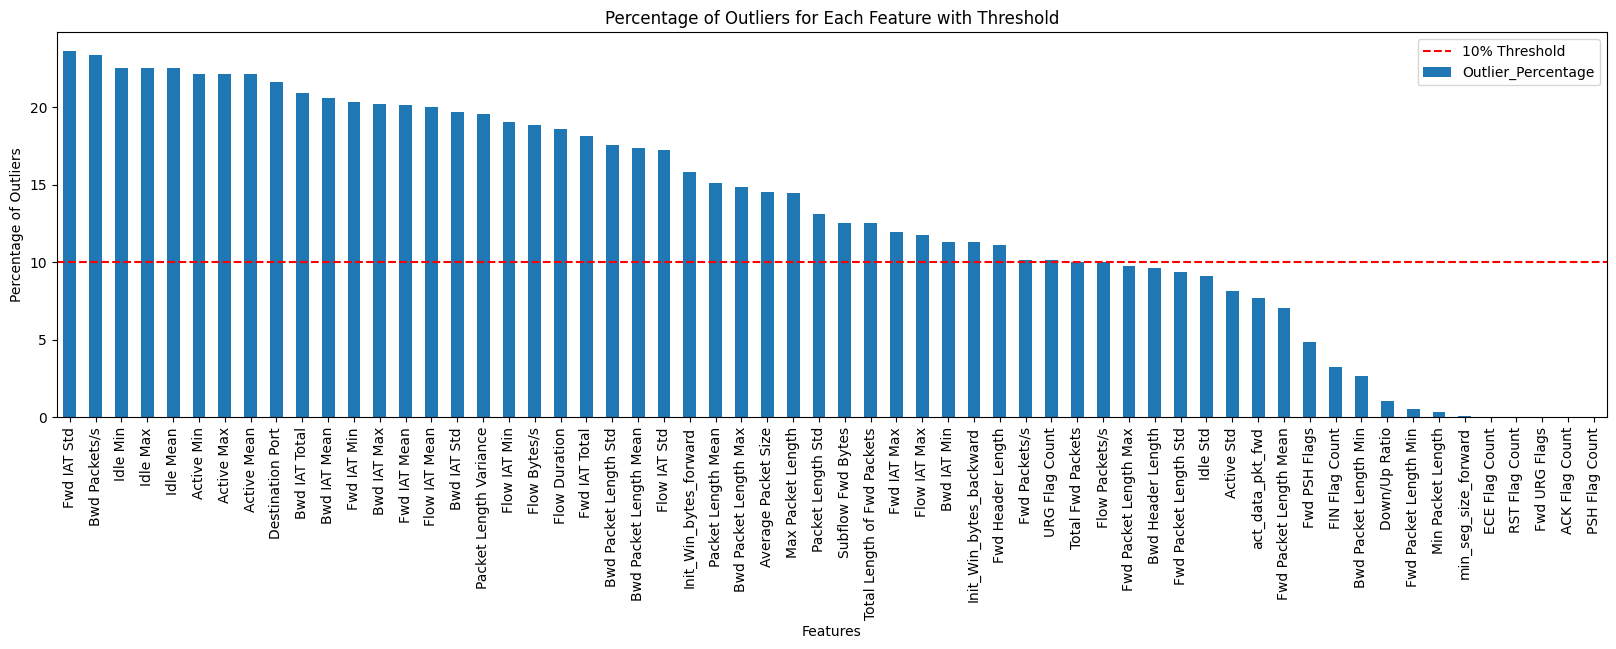

In [43]:
# Calculate outliers percentage
outlier_percentages = calculate_outliers_percentage(data[numeric_features])

# Convert to DataFrame for easier manipulation
outliers_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['Outlier_Percentage'])

# Define the threshold for concern
threshold = 10

# Identify features with high percentage of outliers
high_outlier_features = outliers_df[outliers_df['Outlier_Percentage'] > threshold]

# Plot the outlier percentages and highlight features above the threshold
plt.figure(figsize=(15, 10))
outliers_df.sort_values(by='Outlier_Percentage', ascending=False).plot(kind='bar', legend=False, figsize=(20, 5))
plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold}% Threshold')
plt.xlabel('Features')
plt.ylabel('Percentage of Outliers')
plt.title('Percentage of Outliers for Each Feature with Threshold')
plt.legend()
plt.show()

**IQR 방식으로 각 feature의 이상치 비율 계산 + 시각화**

- 이상치 비율 그래프 생성
- 어떤 변수들이 유독 이상치가 많은지 확인

In [44]:
# Print the features with high outlier percentages
print(f"Features with outlier percentage above {threshold}%:\n")
print(high_outlier_features.sort_values('Outlier_Percentage', ascending=False))

# Cleaning up
del outliers_df

Features with outlier percentage above 10%:

                             Outlier_Percentage
Fwd IAT Std                           23.657989
Bwd Packets/s                         23.402391
Idle Min                              22.501508
Idle Max                              22.501508
Idle Mean                             22.501508
Active Min                            22.167917
Active Max                            22.167917
Active Mean                           22.167917
Destination Port                      21.645137
Bwd IAT Total                         20.926819
Bwd IAT Mean                          20.602908
Fwd IAT Min                           20.366311
Bwd IAT Max                           20.187555
Fwd IAT Mean                          20.126462
Flow IAT Mean                         19.985512
Bwd IAT Std                           19.700319
Packet Length Variance                19.538899
Flow IAT Min                          19.072649
Flow Bytes/s                          18.84

**이상치 비율이 10% 넘는 feature 출력**

- 결과 예시
    - Fwd IAT Std
    - Bwd Packets/s
    - Idle Min
    - Idle Max
    - Idle Mean
    등이 10% 이상

- 이상치가 꽤 많은 편
- 평균/분산 가정이 강한 기법보다 **비모수 통계나 robust한 방법**이 더 적절

## 3.4. Data Distribution

**데이터 분포 분석**

- 정규성 여부 확인 -> 어떤 통계 검정을 써야 좋은지?

In [45]:
norm_dist = 0
not_norm_dist = 0

for col in numeric_features:

    # Perform Anderson-Darling test for normality
    result = stats.anderson(data[col], dist='norm')

    # Compare the statistic with the critical value at 5% significance level
    if result.statistic < result.critical_values[2]:  # 5% significance level
        norm_dist += 1
    else:
        not_norm_dist += 1

print(f'{norm_dist} features are normally distributed')
print(f'{not_norm_dist} features are not normally distributed - Reject null hypothesis')

0 features are normally distributed
60 features are not normally distributed - Reject null hypothesis


**Anderson-Darling 검정으로 정규성 확인**

- `정규분포를 따르는 feature`: 0개
- `정규분포를 따르지 않는 feature`: 60개

- **모든 수치형 feature가 비정규라고 판단**
    - ANOVA 같은 정규성 가정 기반 방법보다 *비모수 방법이 더 적합*하다는 근거가 됨.

## 3.5. Class Imbalance

**클래스 불균형**

In [46]:
# Count occurrences of each attack type and convert to a DataFrame
attack_counts_df = data['Attack Type'].value_counts().reset_index()
attack_counts_df.columns = ['Attack Type', 'Number of Occurrences']

# Counting the total for each attack on both cases
total_occurrences = attack_counts_df['Number of Occurrences'].sum()

# Calculating the respective percentages
attack_counts_df['% of Total'] = ((attack_counts_df['Number of Occurrences'] / total_occurrences) * 100).round(2)

print(attack_counts_df)

      Attack Type  Number of Occurrences  % of Total
0  Normal Traffic                2095057       83.11
1             DoS                 193745        7.69
2            DDoS                 128014        5.08
3   Port Scanning                  90694        3.60
4     Brute Force                   9150        0.36
5     Web Attacks                   2143        0.09
6            Bots                   1948        0.08


**공격 타입별 개수와 전체 대비 비율 계산**

- `Normal Traffic`: 83.11%
- `DoS`: 7.69%
- `DDoS`: 5.08%
- `Port Scanning`: 3.60%
- 그 외 클래스는 매우 적음

- **정상 트래픽이 압도적**
- 나머지 공격 클래스는 매우 적음 -> **클래스 불균형이 너무 심하다**

**클래스 불균형 관찰사항 정리**

- 핵심 포인트
    - Normal Traffic 비중이 너무 큼
    - 일부 클래스는 매우 희소함
    - 모델 평가 시 accuracy만 보면 착시가 생길 수 있음

In [47]:
# Cleaning up
del attack_counts_df

# 4. Feature Importance

**데이터 특성**

- 정규분포 X
- 이상치 많음
- **분산 동질성 보고 어떤 검정 쓸지 판단하자**

In [48]:
# Applying the Levene's Test
# p-value < 0.05 suggests unequal variances among groups (rejecting the null hypothesis of equal variances)
variance_result = analyze_variance_homogeneity(data, numeric_features)

Not enough valid groups to perform Levene's test for feature: Fwd URG Flags
Not enough valid groups to perform Levene's test for feature: RST Flag Count
Not enough valid groups to perform Levene's test for feature: ECE Flag Count


**Levene test 수행**

- 일부 feature는 유효한 그룹이 부족해서 Levene 검정을 못 했다고 나옴
    - `Fwd URG Flags`
    - `RST Flag Count`
    - `ECE Flag Count`

- **일부 변수는 값 구조가 너무 치우쳐 있어서 분산 검정을 제대로 적용하기 어려운 상태**

In [49]:
# Analysing the results
no_significant_results = True

for feature, result in variance_result.items():   
    if result['p-value'] > 0.05:  
        print(f"\nFeature: {feature}")  
        print(f"  - Test Statistic: {result['Statistic']:.4f}")  
        print(f"  - p-value: {result['p-value']:.4f}")  
        print("  - Interpretation: The variances are not significantly different (fail to reject null hypothesis).")  
        no_significant_results = False

# If no features had p-values > 0.05  
if no_significant_results:  
    print("\nNo features have p-values greater than 0.05. All features have significant differences in variance.")


Feature: Fwd Header Length
  - Test Statistic: 0.1504
  - p-value: 0.9890
  - Interpretation: The variances are not significantly different (fail to reject null hypothesis).

Feature: Bwd Header Length
  - Test Statistic: 0.3305
  - p-value: 0.9213
  - Interpretation: The variances are not significantly different (fail to reject null hypothesis).

Feature: min_seg_size_forward
  - Test Statistic: 0.6496
  - p-value: 0.6271
  - Interpretation: The variances are not significantly different (fail to reject null hypothesis).


**Levene test 결과 중 p-value > 0.05인 feature 출력**

- 분산이 유의하게 다르지 않은 feature를 보여주는 셀
- 대부분 feature는 분산 동질성이 만족되지 않음
- 일부만 만족됨

**따라서 ANOVA보다 Kruskal-Wallis가 적절**

- 정규성 불만족
- 분산 동질성도 약함
- 이상치 많음

> **즉, 비모수 검정 사용이 타당하다**

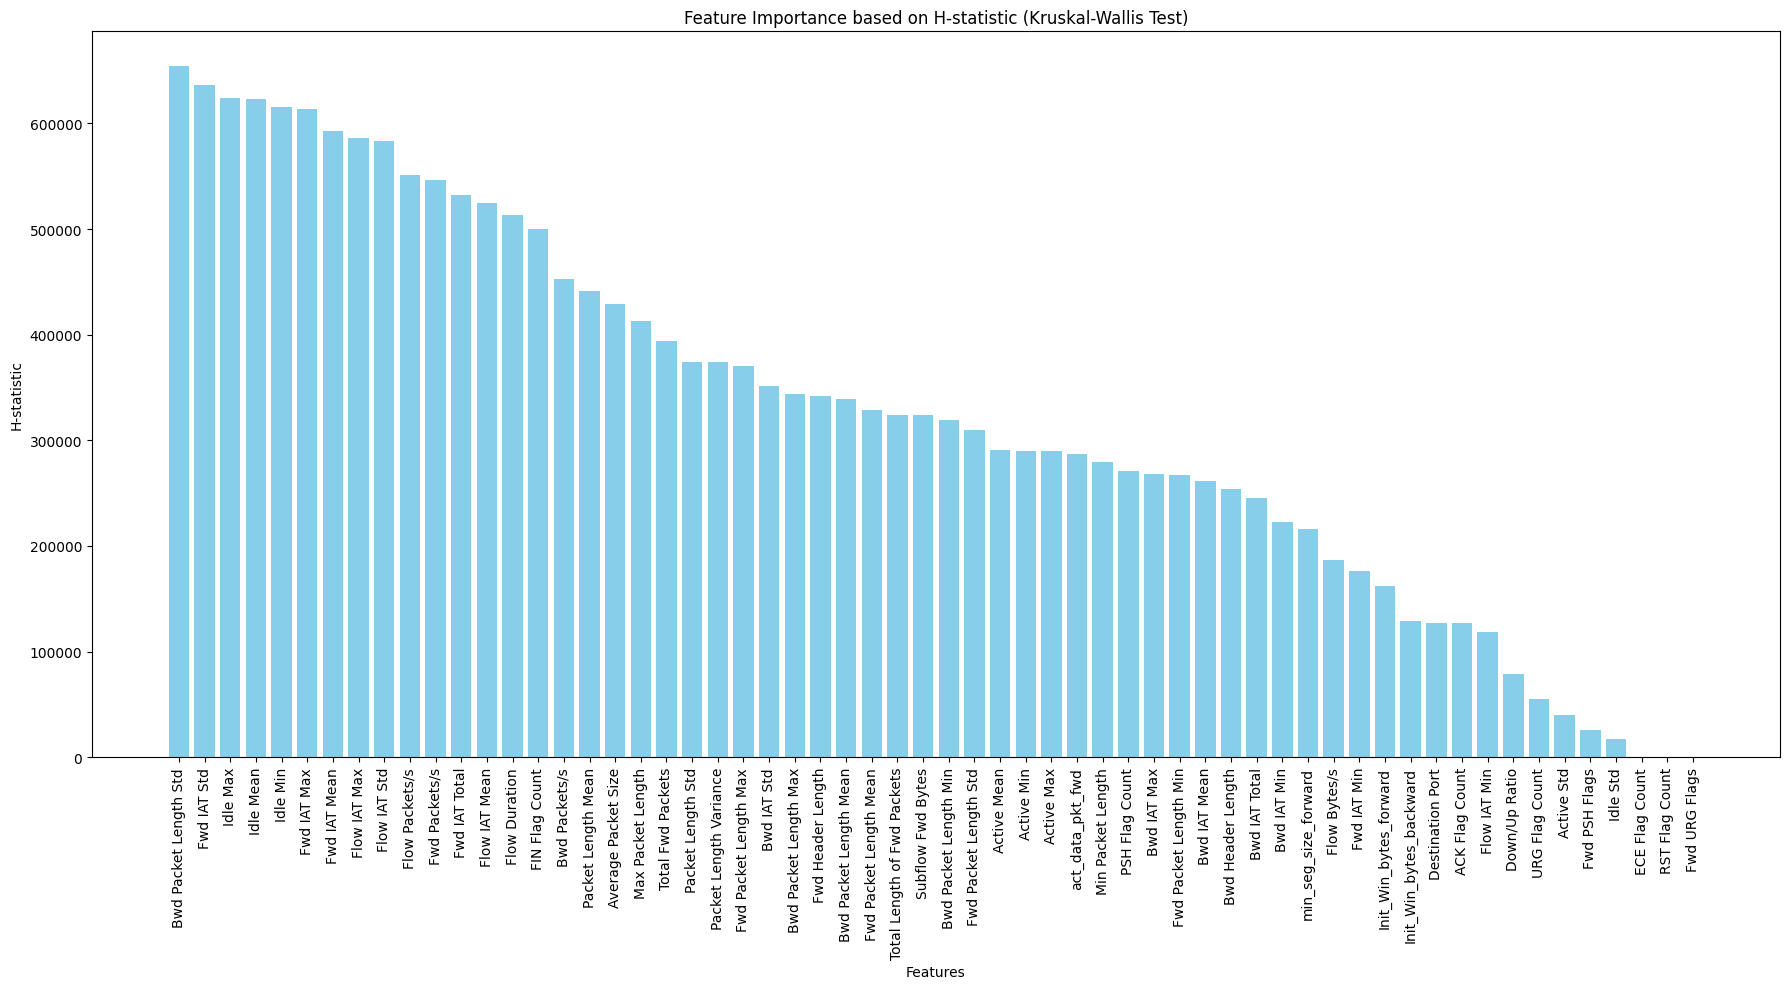

In [50]:
# Analysing feature importance using Kruskal-Wallis.
h_p_stats = analyze_feature_importance(data, numeric_features)

**Kruskal-Wallis 기반 feature importance 분석**

- 각 feature가 공격 타입 간 차이를 *얼마나 잘 설명하는지 통계적으로 평가*

Cross-Validation Score: 0.9986 ± 0.0001

Classification Report:

                precision    recall  f1-score   support

          Bots       0.86      0.74      0.79       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      0.99      0.99     27208
   Web Attacks       0.99      0.97      0.98       643

      accuracy                           1.00    756226
     macro avg       0.98      0.96      0.97    756226
  weighted avg       1.00      1.00      1.00    756226




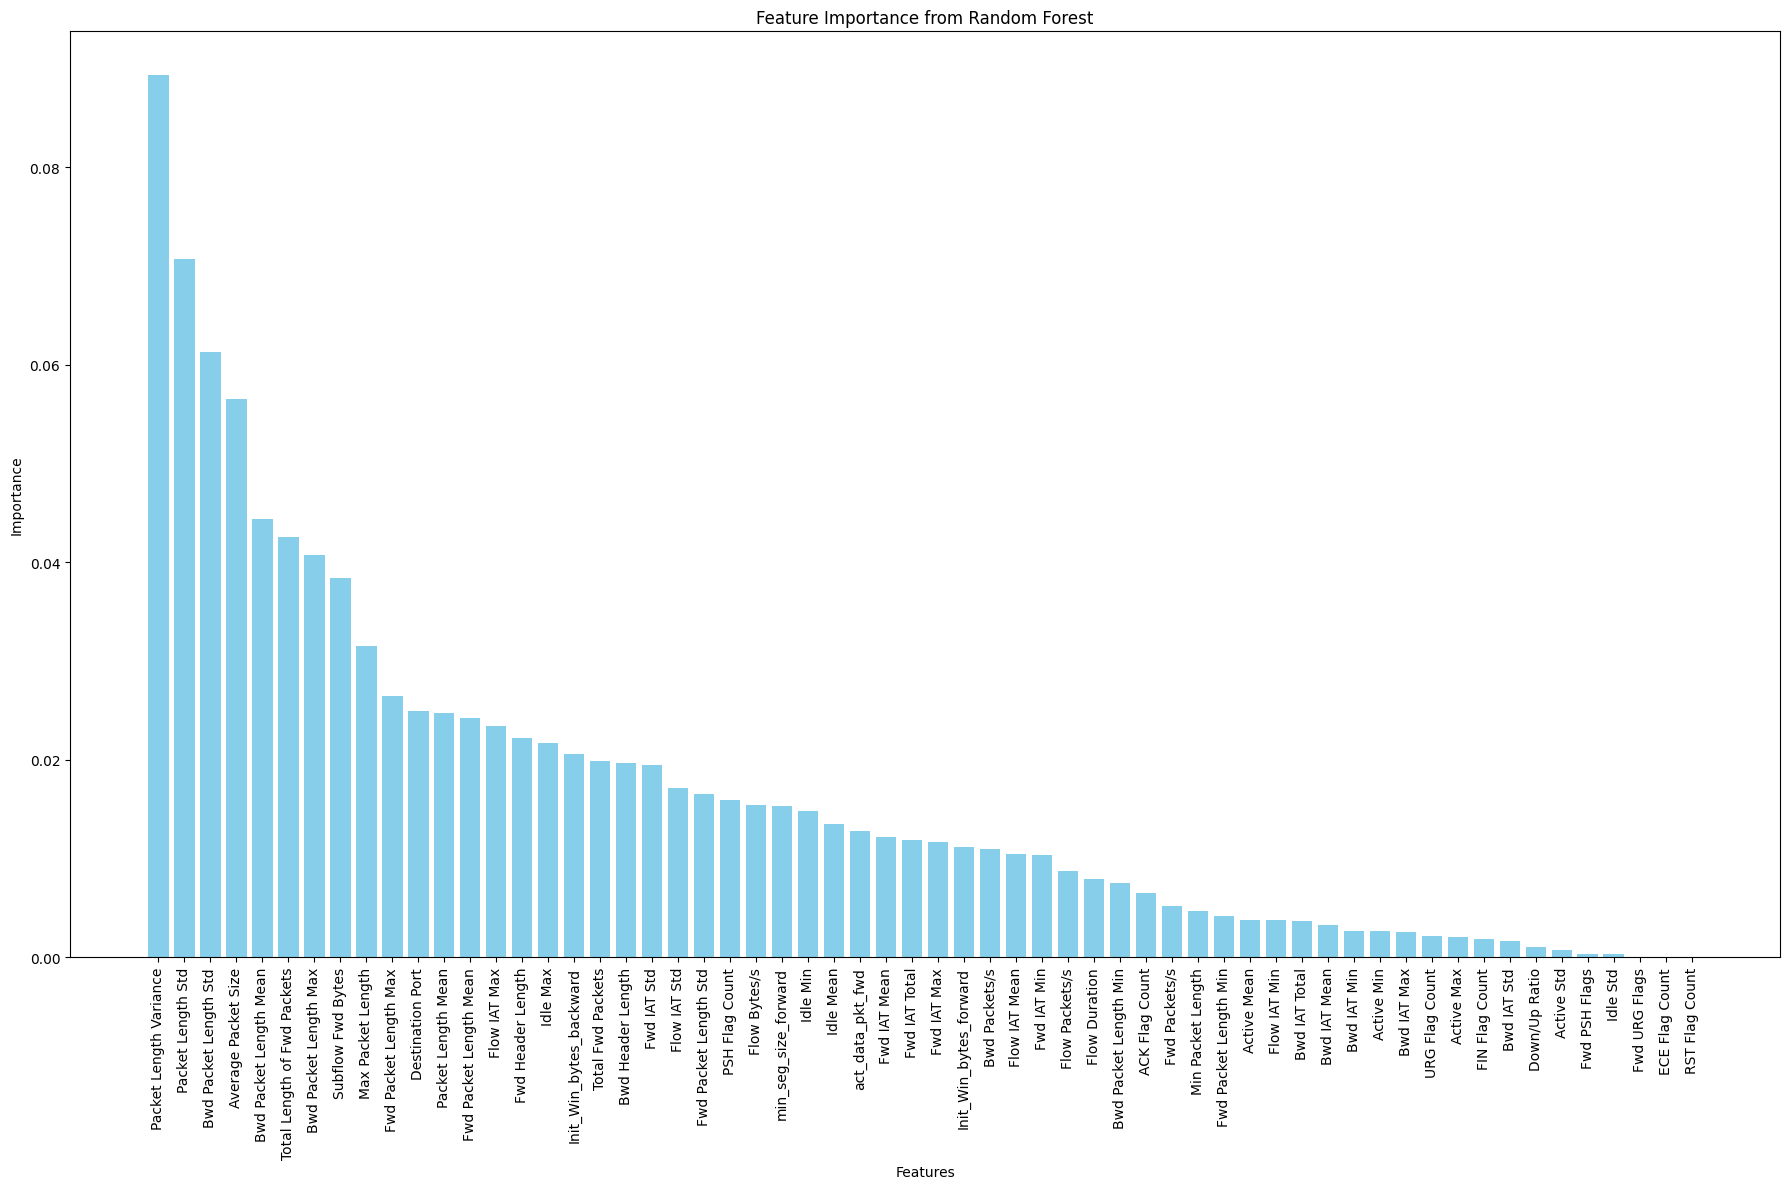

In [51]:
# Analysing feature importance using Tree-Model
feature_importance_tree, cm, rf_labels, cv_scores = analyze_feature_importance_rf(data, numeric_features)

**랜덤포레스트 기반 중요도**

- 통계 검정 기반 중요도와 모델 기반 중요도를 비교
- `Cross-Validation Score`: 0.9986 ± 0.0001
- Classification Report 출력

- 해석
    - 전체적으로 성능이 매우 높음
    - 다만..**데이터셋 특성상 쉽게 구분되는 클래스가 많고 클래스 불균형 영향도 있을 수 있어서 무조건 `완벽하다`라고 해석하면 위험**

- 추가 인사이트
    - `Bots 클래스`의 precision/recall이 다른 클래스보다 상대적으로 낮음
    - **즉, Bot 공격은 상대적으로 구분이 까다로운 편**

**랜덤포레스트 feature importance 설명**

- 트리 모델에서 어떤 feature가 분할에 크게 기여했는가?

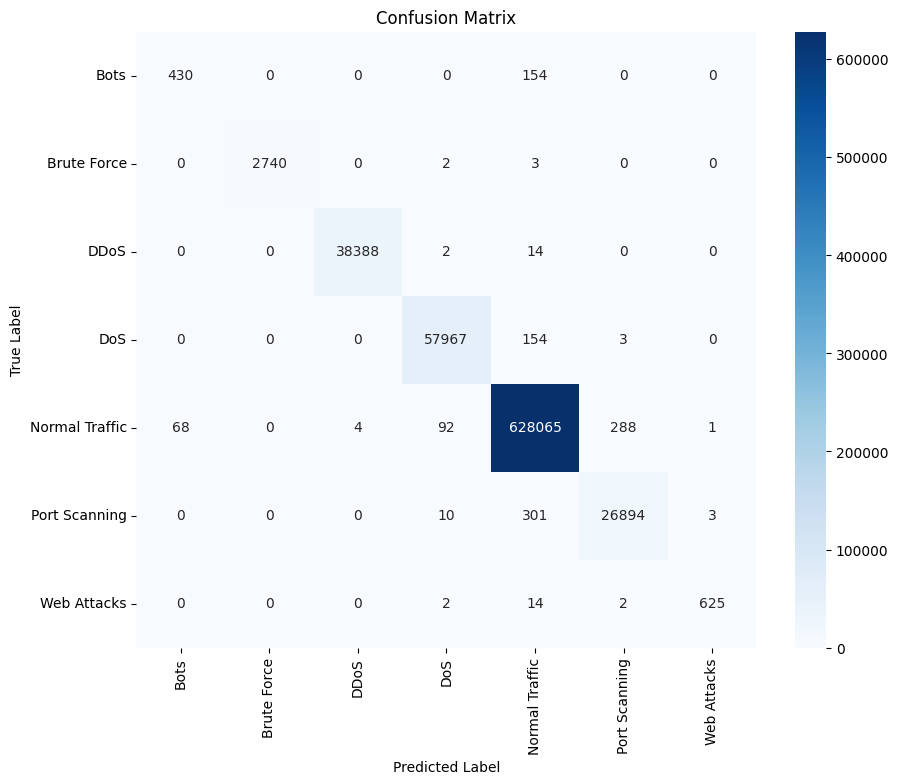

In [52]:
# Evaluating RF performance based on selected features
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_labels, yticklabels=rf_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**Confusion matrix 시각화 : HEATMAP 출력**

- 어떤 클래스가 서로 헷갈렸는지 시각적으로 확인 가능
- 특히 `Bot` 파트가 `normal traffic`으로 일부 잘못 분류되는 문제 ... !!

**랜덤 포레스트 성능 해석**

- 전반 성능은 높지만 `bot 공격` 은 정상 트래픽으로 오분류되는 비율 있음 -> **약점 발생 ... 가능성**

In [53]:
# Preparing the df for comparison
h_p_stats.reset_index(inplace = True)
h_p_stats.rename(columns = {'index':'Feature'}, inplace = True)

# Sorting the new df for easier visualization
comparison_tb = feature_importance_tree.merge(h_p_stats, on = 'Feature', how = 'left')
comparison_tb_sorted = comparison_tb.sort_values(by='Importance', ascending=False)
comparison_tb_sorted

,Feature,Importance,H-statistic,p-value
0,Packet Length Variance,8.931445e-02,373845.434316,0.000000e+00
1,Packet Length Std,7.069681e-02,373896.560353,0.000000e+00
2,Bwd Packet Length Std,6.131436e-02,654400.346609,0.000000e+00
3,Average Packet Size,5.653880e-02,429097.080675,0.000000e+00
4,Bwd Packet Length Mean,4.442698e-02,338820.640791,0.000000e+00
5,Total Length of Fwd Packets,4.252596e-02,324367.440051,0.000000e+00
6,Bwd Packet Length Max,4.078398e-02,343538.176327,0.000000e+00
7,Subflow Fwd Bytes,3.836811e-02,324367.440051,0.000000e+00
8,Max Packet Length,3.153551e-02,413042.599252,0.000000e+00
9,Fwd Packet Length Max,2.642692e-02,370387.060527,0.000000e+00


**랜덤포레스트 중요도와 Kruskal-Wallis 결과를 합친 비교표 생성**

- 결과 예시 상위 feature
    - `Packet Length Variance`
    - `Packet Length Std`
    - `Bwd Packet Length Std`

- 어떤 변수들이 두 방식 모두에서 중요하게 나타나는지 비교 가능

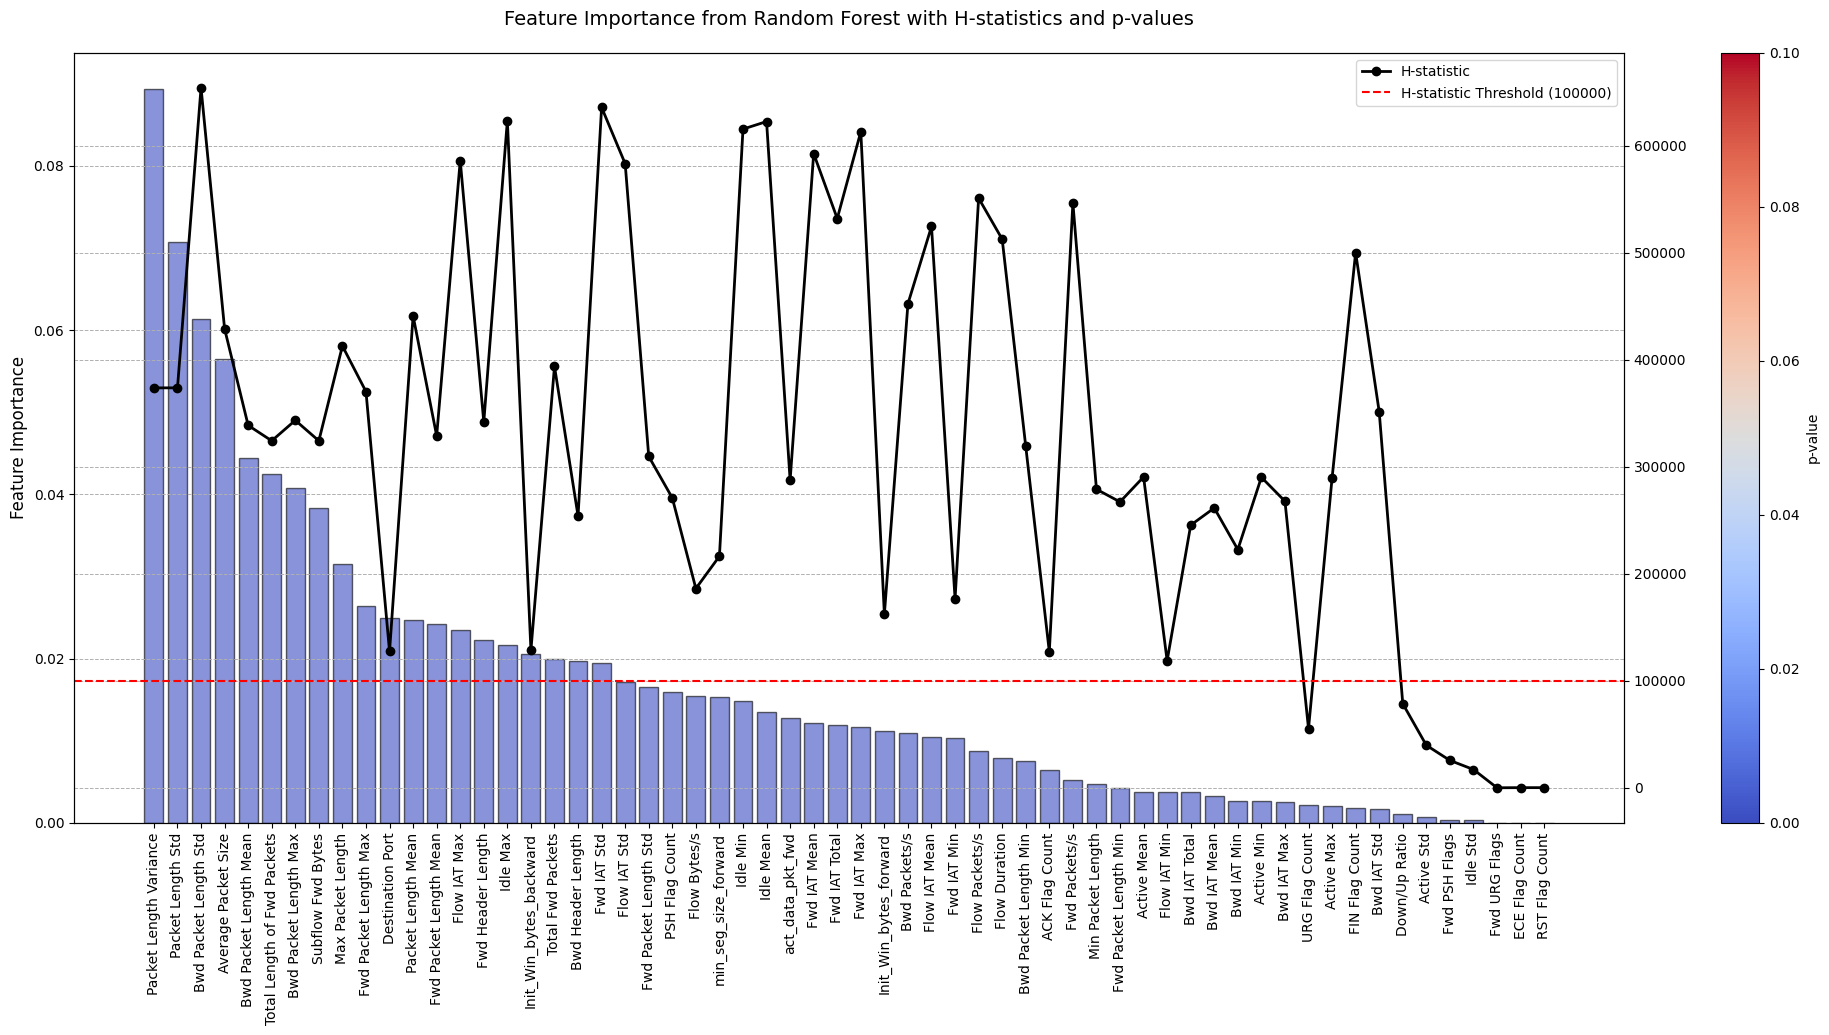

In [54]:
# Create figure and axis
plt.figure(figsize=(25, 10))

# Create a color map based on p-value
colors = sns.color_palette("coolwarm", as_cmap=True)

# Create twin axes for different scales
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot bars for importance
bars = ax1.bar(comparison_tb_sorted['Feature'],
                comparison_tb_sorted['Importance'],
                alpha=0.6,
                color=[colors(0 + (value)) for value in comparison_tb_sorted['p-value']], edgecolor='black')

# Plot line for H-statistic
line = ax2.plot(comparison_tb_sorted['Feature'],
                 comparison_tb_sorted['H-statistic'],
                 color='black',
                 linewidth=2,
                 label='H-statistic',
                 marker='o')

# Add a horizontal threshold line
threshold = 100000
ax2.axhline(y=threshold, color='red', linestyle='--', label=f'H-statistic Threshold ({threshold})')
ax2.legend()

# Customize primary y-axis (Importance)
ax1.set_ylabel('Feature Importance', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set x-ticks and labels
ax1.set_xticks(range(len(comparison_tb_sorted['Feature'])))
ax1.set_xticklabels(comparison_tb_sorted['Feature'], rotation=90, ha='center', fontsize=10)

# Add title
plt.title('Feature Importance from Random Forest with H-statistics and p-values',
          fontsize=14, pad=20)

# Add colorbar for p-values
sm = plt.cm.ScalarMappable(cmap=colors, norm=plt.Normalize(vmin=comparison_tb_sorted['p-value'].min(), vmax=0.1))
cbar = plt.colorbar(sm, ax=ax1, orientation='vertical')
cbar.set_label('p-value', fontsize=10)

# Add gridlines for readability
ax1.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)
ax2.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)

plt.show()


**비교 결과 시각화**

- 랜덤포레스트 중요도, H-statistic, p-value를 함께 보는 복합 시각화
- 해석
    - RF 중요도와 통계 검정 결과가 완전히 같지는 않음
    - **하지만** 상위 중요 feature들에서는 어느 정도 일치가 나타남
    - **반대로** 중요도가 매우 낮고 통계적으로도 약한 변수는 제거 후보가 됨

In [55]:
# Removing statiscally irrelavant features from the dataset
cols_to_remove = ['ECE Flag Count', 'RST Flag Count', 'Fwd URG Flags', 'Idle Std', 'Fwd PSH Flags', 'Active Std', 'Down/Up Ratio', 'URG Flag Count']
data.drop(columns=cols_to_remove, inplace=True)

**통계적으로 중요하지 않은 컬럼 제거**

- 제거 컬럼
    - `ECE Flag Count`
    - `RST Flag Count`
    - `Fwd URG Flags`
    - `Idle Std`
    - `Fwd PSH Flags`
    - `Active Std`
    - `Down/Up Ratio`
    - `URG Flag Count`

- 최종적으로 불필요한 feature를 걷어내는 단계

## 5.1. Overview of the Final Columns

**최종 컬럼**

| **Column Name**                    | **Description**                                                                                                                                             |
|-------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Destination Port                    | The destination port for the flow.                                                                                                                         |
| Flow Duration                       | The duration of the flow.                                                                                                                                   |
| Total Fwd Packets                   | The total number of forwarded packets in the flow.                                                                                                         |
| Total Length of Fwd Packets         | The total length of forwarded packets in the flow.                                                                                                         |
| Fwd Packet Length Max               | The maximum size of forwarded packets.                                                                                                                      |
| Fwd Packet Length Min               | The minimum size of forwarded packets.                                                                                                                     |
| Fwd Packet Length Mean              | The average length of forwarded packets in the flow.                                                                                                       |
| Fwd Packet Length Std               | The standard deviation of forwarded packet lengths in the flow.                                                                                           |
| Bwd Packet Length Max               | The maximum size of backward packets.                                                                                                                       |
| Bwd Packet Length Min               | The minimum size of backward packets.                                                                                                                     |
| Bwd Packet Length Mean              | The average size of backward packets.                                                                                                                       |
| Bwd Packet Length Std               | The standard deviation of backward packet lengths in the flow.                                                                                             |
| Flow Bytes/s                        | The number of bytes transferred per second in the flow.                                                                                                   |
| Flow Packets/s                      | The number of packets transferred per second in the flow.                                                                                                  |
| Flow IAT Mean                       | The average inter-arrival time of packets in the flow.                                                                                                     |
| Flow IAT Std                        | The standard deviation of the inter-arrival times of packets in the flow.                                                                                  |
| Flow IAT Max                        | The maximum inter-arrival time of packets in the flow.                                                                                                      |
| Flow IAT Min                        | The minimum inter-arrival time of packets in the flow.                                                                                                     |
| Fwd IAT Total                       | The total forward inter-arrival time observed during the flow.                                                                                             |
| Fwd IAT Mean                        | The mean forward inter-arrival time observed during the flow.                                                                                              |
| Fwd IAT Std                         | The standard deviation of the forward inter-arrival time during the flow.                                                                                 |
| Fwd IAT Max                         | The maximum forward inter-arrival time observed during the flow.                                                                                           |
| Fwd IAT Min                         | The minimum forward inter-arrival time observed during the flow.                                                                                           |
| Bwd IAT Total                       | The total backward inter-arrival time during the flow.                                                                                                    |
| Bwd IAT Mean                        | The average backward inter-arrival time during the flow.                                                                                                  |
| Bwd IAT Std                         | The standard deviation of the backward inter-arrival time during the flow.                                                                                 |
| Bwd IAT Max                         | The maximum backward inter-arrival time during the flow.                                                                                                  |
| Bwd IAT Min                         | The minimum backward inter-arrival time during the flow.                                                                                                  |
| Fwd Header Length                   | The total length of the header in forwarded packets.                                                                                                       |
| Bwd Header Length                   | The total length of the header in backward packets.                                                                                                        |
| Fwd Packets/s                       | The number of forwarded packets transferred per second in the flow.                                                                                        |
| Bwd Packets/s                       | The number of backward packets transferred per second in the flow.                                                                                        |
| Min Packet Length                   | The minimum packet length observed in the flow.                                                                                                            |
| Max Packet Length                   | The maximum packet length observed in the flow.                                                                                                            |
| Packet Length Mean                  | The average packet length in the flow.                                                                                                                     |
| Packet Length Std                   | The standard deviation of packet lengths in the flow.                                                                                                      |
| Packet Length Variance              | The variance of packet lengths in the flow.                                                                                                                |
| FIN Flag Count                      | The number of FIN flags observed in the flow.                                                                                                               |
| PSH Flag Count                      | The number of PSH flags observed in the flow.                                                                                                               |
| ACK Flag Count                      | The number of ACK flags observed in the flow.                                                                                                               |
| Average Packet Size                 | The average size of the packets in the flow.                                                                                                               |
| Subflow Fwd Bytes                   | The number of bytes in the forwarded subflow.                                                                                                              |
| Init_Win_bytes_forward              | The initial window size in bytes in the forward direction.                                                                                                 |
| Init_Win_bytes_backward             | The initial window size in bytes in the backward direction.                                                                                                |
| act_data_pkt_fwd                    | The number of active data packets forwarded.                                                                                                               |
| min_seg_size_forward                | The minimum segment size forwarded in the flow.                                                                                                            |
| Active Mean                         | The average amount of activity observed during the flow.                                                                                                   |
| Active Max                          | The maximum amount of activity observed during the flow.                                                                                                   |
| Active Min                          | The minimum amount of activity observed during the flow.                                                                                                   |
| Idle Mean                           | The average idle time observed during the flow.                                                                                                            |
| Idle Max                            | The maximum idle time observed during the flow.                                                                                                            |
| Idle Min                            | The minimum idle time observed during the flow.                                                                                                            |
| Attack Type                         | The target class, indicating the type of attack or normal traffic.                                                                                        |


# 6. Outputs

**Sampling/Scaling 관련 주의사항**

- `SMOTE`, `RobustScaler` 같은 처리를 전체 데이터에 먼저 해버리면
     -테스트셋 정보가 학습에 새어 들어가는 **데이터 누수(data leakage)**가 생길 수 있음

- 따라서 이런 처리는 **train/test split 이후**에 해야 한다!!

> **이건 아주 중요한 머신러닝 실무 포인트**

In [56]:
# Clean dataset to a CSV file
data.to_csv('cicids2017_cleaned.csv', index=False)

# 7. 요약

**1. 데이터 규모**

원본 병합 후 총 `2,830,743행, 79열`

**2. 데이터 정제**
- 중복행 `308,381개` 제거
- 중복 컬럼 제거
- 무한대값을 결측치로 변환
- 결측치 포함 행 `1,564개` 제거
- 단일값 컬럼 제거

**3. 라벨 처리**
- 세부 공격명을 상위 공격군으로 그룹화
- 너무 희소한 공격 클래스(`Infiltration`, `Miscellaneous`) 제거

**4. EDA 결과**
- 강한 상관관계를 가진 변수 다수 존재
- 이상치 비율이 높은 변수 다수 존재
- 60개 수치형 변수 모두 비정규분포
- 클래스 불균형이 매우 심함
- 정상 트래픽이 전체의 약 83.11%

**5. 중요 변수 분석**
- `Kruskal-Wallis`와 `Random Forest`를 함께 사용해 feature importance 평가
- 중요도가 낮고 통계적으로도 불리한 변수 제거

**6. 최종 결과**
머신러닝 학습에 사용할 수 있는 정제된` cicids2017_cleaned.csv` 생성

# Unsupervised Learning Models for Anomaly-Based Intrusion Detection

In [1]:
# Installing extra components
!pip install memory_profiler
!pip install psutil

In [2]:
# Importing the relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, davies_bouldin_score, calinski_harabasz_score

import time
import psutil
import threading
from memory_profiler import memory_usage

import joblib

# Helper Functions

In [ ]:
# Apply Isolation Forest with resource measurements
def apply_if(X_train, y_train=None, best_params=None, random_state=42, n_jobs=-1):
   
    measurement_if = {}

    # Default to empty dictionary if best_params is not provided
    best_params = best_params or {}

    if_model = IsolationForest(**best_params, random_state=random_state, n_jobs=n_jobs)
    
    # Function to monitor CPU usage during training
    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    # Function to train the model
    def train_model():
        if_model.fit(X_train)

    try:
        # Start CPU monitoring in a separate thread
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        # Measure memory usage and training time
        start_time = time.time()
        train_memory_if = max(memory_usage((train_model,)))  # Measure peak memory usage
        training_time = time.time() - start_time

        # Stop CPU monitoring
        stop_flag.set()
        cpu_thread.join()

        # Add measurements
        measurement_if['Memory Usage (MB)'] = train_memory_if
        measurement_if['Training Time (s)'] = training_time
        measurement_if['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_if['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement_if, if_model

    except Exception as e:
        print(f"Error during Isolation Forest training: {e}")
        return None, None

In [ ]:
# Apply K-means with resource measurements
def apply_kmeans(X, n_clusters=7, random_state=42, n_init='auto'):
    
    measurement_kmeans = {}
    
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)

    # Function to monitor CPU usage during training
    cpu_usage = []
    stop_flag = threading.Event()
    
    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))
    
    # Function to train the model
    def train_model():
        kmeans_model.fit(X)
    
    try:
        # Start CPU monitoring in a separate thread
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()
        
        # Measure memory usage and training time
        start_time = time.time()
        train_memory_kmeans = max(memory_usage((train_model,)))  # Measure peak memory usage
        training_time = time.time() - start_time
        
        # Stop CPU monitoring
        stop_flag.set()
        cpu_thread.join()
        
        # Add measurements
        measurement_kmeans['Memory Usage (MB)'] = train_memory_kmeans
        measurement_kmeans['Training Time (s)'] = training_time
        measurement_kmeans['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_kmeans['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0
        
        # Get cluster labels
        labels = kmeans_model.labels_
        
        return kmeans_model, labels, measurement_kmeans
    
    except Exception as e:
        print(f"Error during K-Means training: {e}")
        return None, None, None

In [ ]:
# Find optimal number of clusters for K-Means
def find_optimal_k(X, k_range, random_state=42, n_init=10):

    results = {
        'k_values': list(k_range),
        'inertia': [],
        'davies_bouldin': [],
        'calinski_harabasz': []
    }
    
    for k in k_range:
        print(f"Testing with k={k}...")
        # Train K-Means
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        kmeans.fit(X)
        labels = kmeans.labels_
        
        # Calculate metrics
        results['inertia'].append(kmeans.inertia_)
        results['davies_bouldin'].append(davies_bouldin_score(X, labels))
        results['calinski_harabasz'].append(calinski_harabasz_score(X, labels))
    
    return results

# 1. Data Preparation: Test/Train Split and Scaling

In [6]:
# Loading the dataset
clean_df = pd.read_csv('/kaggle/input/cicids2017_cleaned.csv')

In [7]:
# Preparing features and truth labels
X = clean_df.drop('Attack Type', axis=1)
y = clean_df['Attack Type']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 1.1 Feature Scaling

In [8]:
# Initializing RobustScaler
scaler = RobustScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test and validation set using the fitted scaler
X_test_scaled = scaler.transform(X_test)

| **Model**                  | **Is Scaling Important?** | **Explanation**                                                                 |
|----------------------------|---------------------------|---------------------------------------------------------------------------------|
| **K-Means Clustering**     | Yes                       | K-Means relies on distance metrics to form clusters; unscaled features can dominate the clustering process, leading to biased or inaccurate results. |
| **Isolation Forest**       | No                        | Isolation Forest uses tree-based structures, which are not sensitive to feature scaling. It isolates anomalies without relying on distance metrics, so scaling is not critical. |

In [9]:
# Exporting the scaler in case it is needed during deployment
joblib.dump(scaler, 'robust_scaler.joblib')

['robust_scaler.joblib']

## 1.2 Binary Classification

| **Algorithm**       | **Better with Binary Approach?** | **Why?**                                                                                          |
|---------------------|----------------------------------|--------------------------------------------------------------------------------------------------|
| **K-Means**          | ✅ Yes                           | K-Means might struggle with multiple attack classes because it treats all clusters equally. A binary approach simplifies the problem, as it focuses on distinguishing normal traffic from all types of anomalies, reducing the complexity of cluster interpretation. |
| **Isolation Forest** | ✅ Yes                           | Isolation Forest performs well with a binary approach because it's designed to isolate anomalies. Treating attacks as anomalies (vs. normal traffic) simplifies the problem, improving the model's ability to detect anomalies. Multiclass would require it to separate multiple attack types, complicating the task. |


In [10]:
# Simplifying the target variable into two classes for the training set 
y_train_bin = y_train.apply(lambda x: 1 if x != 'Normal Traffic' else 0)

# Simplifying the target variable into two classes for the test set
y_test_bin = y_test.apply(lambda x: 1 if x != 'Normal Traffic' else 0)

In [11]:
# Checking the target variable
print(y_train_bin.value_counts())
print(y_test_bin.value_counts())

Attack Type
0    1466539
1     297986
Name: count, dtype: int64
Attack Type
0    628518
1    127708
Name: count, dtype: int64


In [12]:
# Cleaning up
del X, y, clean_df

**Final sets for training and evaluation**

*Scaled:*
- X_train_scaled, y_train
- X_test_scaled, y_test

*Raw*
- X_train, y_train
- X_test, y_test

*Binary classes*
- y_train_bin
- y_test_bin

# 2. Unsupervised Learning

## 2.1 Isolation Forest

### 2.1.1. Hyperparameter Tuning

**Contamination of the training set**

- Normal traffic: 1466539
- Attacks: 297986

$$
\frac{297986 \times 100}{1466539 + 297986} = \frac{29798600}{1764525} \approx 16.89\%
$$

In [ ]:
# Defining the parameters for the Isolation Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': [256, 512, 'auto'],
    'contamination': [0.169],
    'max_features': [0.5, 0.7, 1.0]
}

In [ ]:
# Custom scoring function to use for parameter tuning
def custom_score(estimator, X, y, contamination=0.169):

    anomaly_scores = estimator.decision_function(X)
    threshold = np.percentile(anomaly_scores, 100 * (1 - contamination))
    
    y_pred = (anomaly_scores <= threshold).astype(int)
    
    return f1_score(y, y_pred, pos_label=1, average='binary')

In [ ]:
# Setting up RandomizedSearchCV
if_model = IsolationForest(random_state=42, n_jobs=-1)
random_search_if = RandomizedSearchCV(
    estimator=if_model, 
    param_distributions=param_grid, 
    n_iter=27,
    scoring=custom_score,
    cv=2, 
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [16]:
# Using binary labels for tuning
random_search_if.fit(X_train, y_train_bin)

Fitting 2 folds for each of 27 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


RandomizedSearchCV(cv=2, estimator=IsolationForest(n_jobs=-1, random_state=42),
                   n_iter=27, n_jobs=-1,
                   param_distributions={'contamination': [0.169],
                                        'max_features': [0.5, 0.7, 1.0],
                                        'max_samples': [256, 512, 'auto'],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42,
                   scoring=<function custom_score at 0x7a3e181275b0>,
                   verbose=2)

In [17]:
print(f'Best Parameters: {random_search_if.best_params_}')
print(f'Best Score: {random_search_if.best_score_}')

best_params_if = random_search_if.best_params_

del random_search_if

Best Parameters: {'n_estimators': 200, 'max_samples': 512, 'max_features': 1.0, 'contamination': 0.169}
Best Score: 0.3377656935422071


### 2.1.2 Fitting the Isolation Forest

In [18]:
# Training the model with binary classification
measurement_if, if_model = apply_if(X_train, best_params=best_params_if)

# Get anomaly scores for the test set (higher = more likely anomaly)
anomaly_scores = -if_model.decision_function(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [19]:
# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test_bin, anomaly_scores)

# Choose the threshold where TPR - FPR is maximized (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Classify anomalies
y_pred_if = (anomaly_scores >= optimal_threshold).astype(int)

In [20]:
# Evaluating the model performance against true labels
accuracy_if_binary = accuracy_score(y_test_bin, y_pred_if)
precision_if_binary = precision_score(y_test_bin, y_pred_if)
recall_if_binary = recall_score(y_test_bin, y_pred_if)
f1_if_binary = f1_score(y_test_bin, y_pred_if)

print(f'Binary Classification Metrics:')
print(f'Accuracy: {accuracy_if_binary:.4f}')
print(f'Precision: {precision_if_binary:.4f}')
print(f'Recall: {recall_if_binary:.4f}')
print(f'F1-Score: {f1_if_binary:.4f}')

Binary Classification Metrics:
Accuracy: 0.7781
Precision: 0.3972
Recall: 0.6064
F1-Score: 0.4800


In [21]:
# Checking computational cost
print("Resource measurements:", measurement_if)

Resource measurements: {'Memory Usage (MB)': 3538.82421875, 'Training Time (s)': 142.1897075176239, 'Peak CPU Usage (%)': 90.0, 'Average CPU Usage (%)': 27.87191489361693}


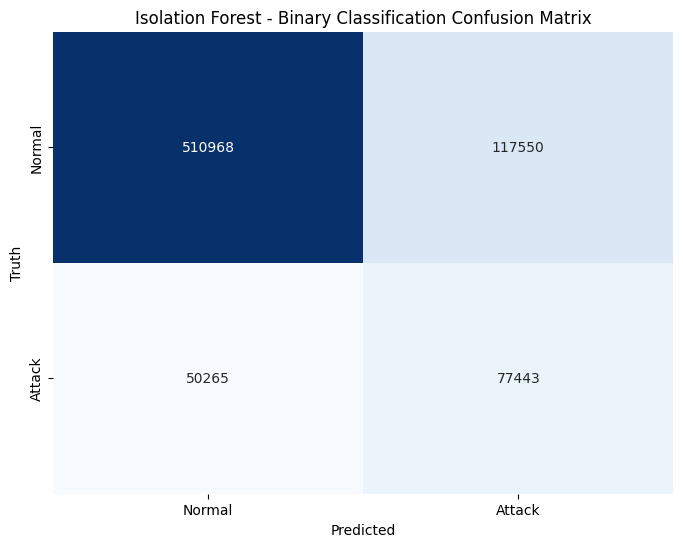

In [22]:
# Confusion Matrix for Binary Classification
cm_if_binary = confusion_matrix(y_test_bin, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_if_binary, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - Binary Classification Confusion Matrix')
plt.show()

In [23]:
# Classification report
print(classification_report(y_test_bin, y_pred_if, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.91      0.81      0.86    628518
      Attack       0.40      0.61      0.48    127708

    accuracy                           0.78    756226
   macro avg       0.65      0.71      0.67    756226
weighted avg       0.82      0.78      0.79    756226




| **Model**            | **Accuracy** | **Precision (Normal)** | **Precision (Anomaly)** | **Recall (Normal)** | **Recall (Anomaly)** | **F1 Score (Normal)** | **F1 Score (Anomaly)** |
|----------------------|--------------|------------------------|-------------------------|---------------------|----------------------|-----------------------|------------------------|
| **Reference (IF)**   | 0.79         | 0.45                   | 0.83                    | 0.23                | 0.93                 | 0.30                  | 0.88                   |
| **IF**          | 0.78         | 0.91                   | 0.40                    | 0.81                | 0.61                 | 0.86                  | 0.48        |

### 2.1.3 Exporting the Model

In [24]:
# Save the model to a file
joblib.dump(if_model, 'isolation_forest.joblib')

['isolation_forest.joblib']

## 2.2. K-means

### 2.2.1. Finding Optimal Number of Clusters

In [25]:
# Find optimal k
k_range = range(2, 15)
results = find_optimal_k(X_train_scaled, k_range)

Testing with k=2...
Testing with k=3...
Testing with k=4...
Testing with k=5...
Testing with k=6...
Testing with k=7...
Testing with k=8...
Testing with k=9...
Testing with k=10...
Testing with k=11...
Testing with k=12...
Testing with k=13...
Testing with k=14...


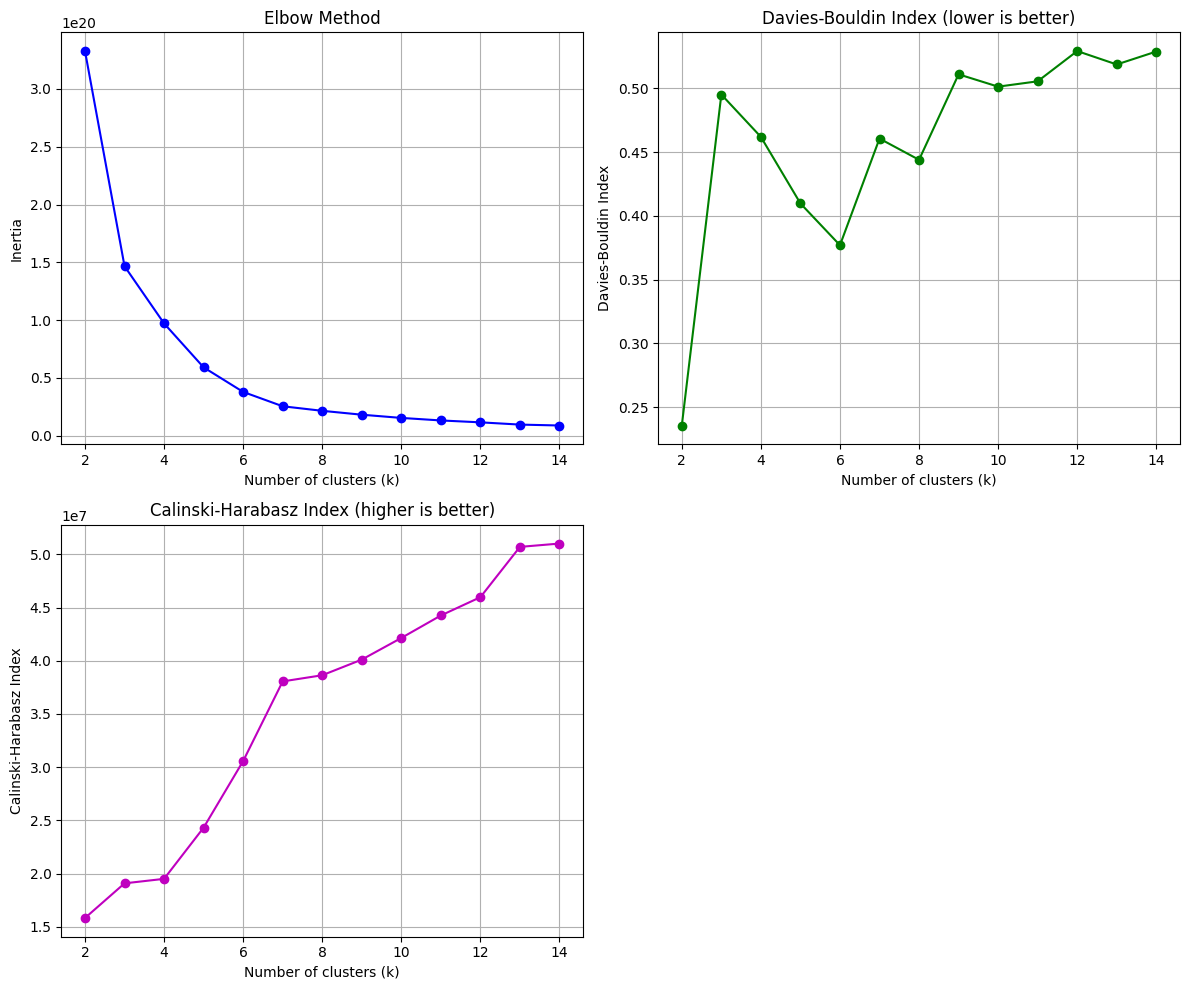

In [26]:
# Plotting results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot inertia (Elbow method)
axes[0, 0].plot(results['k_values'], results['inertia'], 'bo-')
axes[0, 0].set_xlabel('Number of clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True)

# Plot Davies-Bouldin index
axes[0, 1].plot(results['k_values'], results['davies_bouldin'], 'go-')
axes[0, 1].set_xlabel('Number of clusters (k)')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index (lower is better)')
axes[0, 1].grid(True)

# Plot Calinski-Harabasz index
axes[1, 0].plot(results['k_values'], results['calinski_harabasz'], 'mo-')
axes[1, 0].set_xlabel('Number of clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].set_title('Calinski-Harabasz Index (higher is better)')
axes[1, 0].grid(True)

fig.delaxes(axes[1, 1])
plt.tight_layout()
plt.show()

### 2.2.2. Fitting the K-means Model

In [27]:
# Fitting the model
kmeans_model, cluster_labels, measurement_kmeans = apply_kmeans(X_train_scaled, n_clusters=3)

# Making predictions on test set
test_cluster_labels = kmeans_model.predict(X_test_scaled)

In [28]:
# Determine the "Normal" Cluster
cluster_counts = pd.Series(cluster_labels).value_counts()

# Assume the largest cluster is "normal"
normal_cluster = cluster_counts.idxmax()


In [29]:
# Assign "0" to the normal cluster and "1" to all other clusters
y_pred_kmeans = (test_cluster_labels != normal_cluster).astype(int)

In [30]:
# Evaluating computational cost
print("Resource measurements:", measurement_kmeans)

Resource measurements: {'Memory Usage (MB)': 3952.8828125, 'Training Time (s)': 3.017977476119995, 'Peak CPU Usage (%)': 100.0, 'Average CPU Usage (%)': 62.00666666666667}


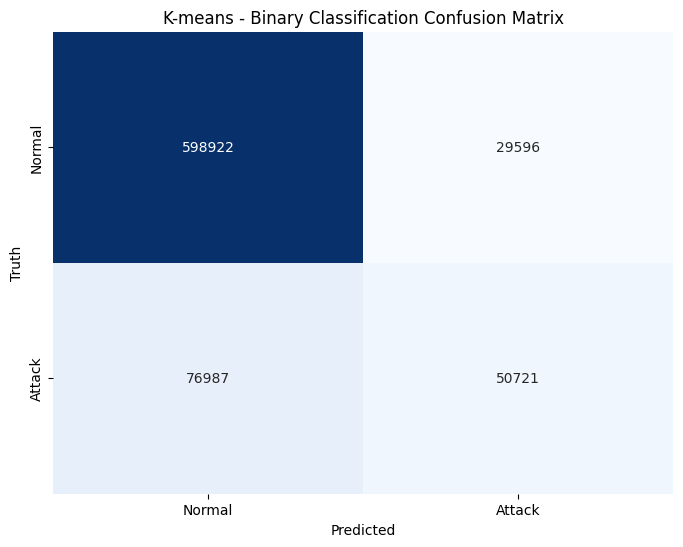

In [31]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test_bin, y_pred_kmeans)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('K-means - Binary Classification Confusion Matrix')
plt.show()

In [32]:
# Classification report
print(classification_report(y_test_bin, y_pred_kmeans, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92    628518
      Attack       0.63      0.40      0.49    127708

    accuracy                           0.86    756226
   macro avg       0.76      0.68      0.70    756226
weighted avg       0.84      0.86      0.85    756226



| **Model**            | **Accuracy** | **Precision (Normal)** | **Precision (Anomaly)** | **Recall (Normal)** | **Recall (Anomaly)** | **F1 Score (Normal)** | **F1 Score (Anomaly)** | 
|----------------------|--------------|------------------------|-------------------------|---------------------|----------------------|-----------------------|------------------------|
| **Reference (K-Means)** | 0.79         | 0.84                   | 0.46                    | 0.91                | 0.31                 | 0.88                  | 0.37                   |
| **K-Means**      | 0.86         | 0.89                   | 0.63                    | 0.95                | 0.40                 | 0.92                  | 0.49                   |

### 2.2.3. Exporting the Model

In [33]:
# Save the model and scaler to files
joblib.dump(kmeans_model, 'kmeans_model.joblib')

['kmeans_model.joblib']

# 3. Comparing Performance Results

In [34]:
# Calculating precision, recall, and F1 score for each unsupervised model
precision_if = precision_score(y_test_bin, y_pred_if, average='weighted')
recall_if = recall_score(y_test_bin, y_pred_if, average='weighted')
f1_if = f1_score(y_test_bin, y_pred_if, average='weighted')
accuracy_if = accuracy_score(y_test_bin, y_pred_if)

precision_kmeans = precision_score(y_test_bin, y_pred_kmeans, average='weighted')
recall_kmeans = recall_score(y_test_bin, y_pred_kmeans, average='weighted')
f1_kmeans = f1_score(y_test_bin, y_pred_kmeans, average='weighted')
accuracy_kmeans = accuracy_score(y_test_bin, y_pred_kmeans)

In [35]:
# Creating the results dataframe
unsupervised_results = pd.DataFrame({
    'Model': ['Isolation Forest', 'K-Means'],
    'Accuracy': [accuracy_if, accuracy_kmeans],
    'Precision': [precision_if, precision_kmeans],
    'Recall': [recall_if, recall_kmeans],
    'F1 Score': [f1_if, f1_kmeans],
    'Memory Usage (MB)': [measurement_if['Memory Usage (MB)'], measurement_kmeans['Memory Usage (MB)']],
    'Training Time (s)': [measurement_if['Training Time (s)'], measurement_kmeans['Training Time (s)']],
    'Peak CPU Usage (%)': [measurement_if['Peak CPU Usage (%)'], measurement_kmeans['Peak CPU Usage (%)']],
    'Average CPU Usage (%)': [measurement_if['Average CPU Usage (%)'], measurement_kmeans['Average CPU Usage (%)']],
})

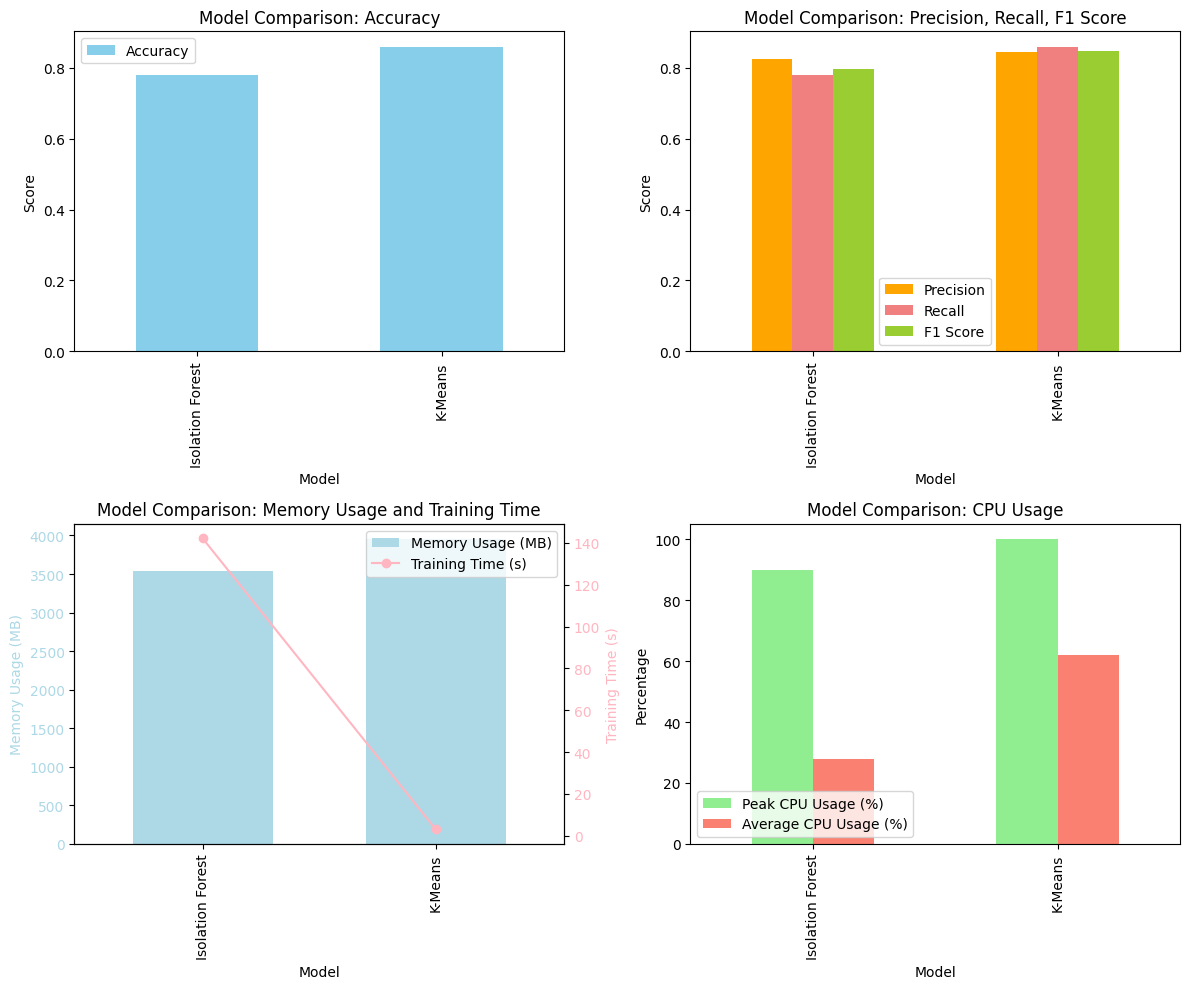

In [36]:
# Plotting the comparison for accuracy, metrics, and performance
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plotting Accuracy
unsupervised_results.set_index('Model')['Accuracy'].plot(kind='bar', ax=axes[0, 0], color='skyblue', legend=True)
axes[0, 0].set_title('Model Comparison: Accuracy')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xlabel('Model')

# Plotting Precision, Recall, F1 Score
unsupervised_results.set_index('Model')[['Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=axes[0, 1], color=['orange', 'lightcoral', 'yellowgreen'], legend=True)
axes[0, 1].set_title('Model Comparison: Precision, Recall, F1 Score')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xlabel('Model')

# Plotting Memory Usage and Training Time
ax1 = axes[1, 0]

unsupervised_results.set_index('Model')['Memory Usage (MB)'].plot(
    kind='bar', ax=ax1, color='lightblue', label='Memory Usage (MB)', width=0.6
)
ax1.set_ylabel('Memory Usage (MB)', color='lightblue')
ax1.tick_params(axis='y', labelcolor='lightblue')

ax2 = ax1.twinx() 
unsupervised_results.set_index('Model')['Training Time (s)'].plot(
    ax=ax2, color='lightpink', marker='o', label='Training Time (s)'
)
ax2.set_ylabel('Training Time (s)', color='lightpink')
ax2.tick_params(axis='y', labelcolor='lightpink')

ax1.set_title('Model Comparison: Memory Usage and Training Time')
ax1.set_xlabel('Model')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# Plotting Peak and Average CPU Usage
unsupervised_results.set_index('Model')[['Peak CPU Usage (%)', 'Average CPU Usage (%)']].plot(kind='bar', ax=axes[1, 1], color=['lightgreen', 'salmon'], legend=True)
axes[1, 1].set_title('Model Comparison: CPU Usage')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].set_xlabel('Model')
axes[1, 1].legend(loc='lower left')

plt.tight_layout()
plt.show()

# CICIDS2017 비지도학습 모델 비교 요약

## 1. 프로젝트 개요
전처리가 완료된 **CICIDS2017 데이터셋**을 바탕으ㅀ
비지도학습 기반 이상 탐지 모델을 적용하고 성능을 비교하는 과정을 다룸

- 주요 목적 : **정상 트래픽과 공격 트래픽을 이진 분류(binary classification)** 형태로 단순화한 뒤 대표적인 비지도학습 기법인 **Isolation Forest**와 **K-Means**를 적용 -> *침입 탐지 가능성을 평가*


## 2. 흐름

1. 전처리된 데이터셋 불러오기  
2. 입력 변수(X)와 정답 라벨(y) 분리  
3. `RobustScaler`를 사용한 feature scaling 수행  
4. 다중 공격 라벨을 **정상(0) / 공격(1)** 형태의 이진 분류로 변환  
5. **Isolation Forest** 학습 및 하이퍼파라미터 탐색  
6. **K-Means** 군집화 및 최적 군집 수 탐색  
7. 두 모델의 분류 성능 및 자원 사용량 비교  
8. 최종적으로 비지도학습 모델의 한계와 활용 가능성 해석


## 3. 데이터 준비

- 정상 트래픽: `0`
- 공격 트래픽: `1`

학습 데이터의 클래스 분포: 

- 정상: **1,466,539개**
- 공격: **297,986개**

테스트 데이터의 클래스 분포:

- 정상: **628,518개**
- 공격: **127,708개**

즉, 이 데이터셋은 여전히 **정상 클래스가 훨씬 많은 불균형 데이터**라는 특징을 가짐


## 4. Feature Scaling
`RobustScaler`를 사용하여 feature scaling
    - 중앙값과 IQR(사분위 범위)을 기반으로 스케일링
    - 이상치가 많은 네트워크 트래픽 데이터에 비교적 안정적으로 적용 가능

- 이 단계는 특히 거리 기반 알고리즘인 **K-Means**에 중요
- Isolation Forest에도 feature scale 차이의 영향을 줄이는 데 도움을 줌
- 학습된 스케일러는 추후 배포 또는 재사용을 위해 별도로 저장됨


## 5. Isolation Forest 요약

### 5.1 모델 목적
이상치를 고립시키는 방식으로 탐지하는 비지도학습 알고리즘
정상 데이터가 다수를 차지하고 공격 데이터가 상대적으로 드물다는 점 -> 침입 탐지 문제에 자연스럽게 적용 가능

### 5.2 하이퍼파라미터 튜닝
Isolation Forest는 비지도학습 -> 일반적인 지도학습처럼 직접적인 라벨 기반 튜닝이 어려움
따라서 **사용자 정의 평가 방식을 구성** 후  
`RandomizedSearchCV`를 이용해 주요 하이퍼파라미터를 탐색

최적 파라미터 : 

- `n_estimators = 200`
- `max_samples = 512`
- `max_features = 1.0`
- `contamination = 0.169`

최적 점수 : 

- **Best Score: 0.3378**

### 5.3 예측 방식
모델 학습 후 테스트 데이터에 대해 `anomaly score를 계산`
`ROC curve를 이용해 최적 threshold를 선택`하여  
**정상/공격 이진 분류 결과를 생성**한다.

### 5.4 성능 결과

- Accuracy: **0.7781**
- Precision: **0.3972**
- Recall: **0.6064**
- F1-score: **0.4800**

클래스별 결과 : 

#### Normal 클래스
- Precision: **0.91**
- Recall: **0.81**
- F1-score: **0.86**

#### Attack 클래스
- Precision: **0.40**
- Recall: **0.61**
- F1-score: **0.48**

### 5.5 자원 사용량
Isolation Forest 학습 시 측정된 자원 사용량 : 

- Memory Usage: **3538.82 MB**
- Training Time: **142.19 s**
- Peak CPU Usage: **90.0%**
- Average CPU Usage: **27.87%**

### 5.6 해석
Isolation Forest는 공격을 어느 정도 탐지하지만 
공격 클래스의 precision이 낮아 **오탐(false positive)** 이 비교적 많음
즉, 공격을 놓치지 않으려는 경향은 있으나 정상 트래픽도 공격으로 잘못 탐지하는 경우가 존재함


## 6. K-Means 요약

### 6.1 모델 목적
데이터를 거리 기반으로 여러 군집으로 나누는 비지도학습 알고리즘
군집 생성 후 **가장 큰 군집을 정상 트래픽 군집**으로 가정 -> 나머지 군집을 공격으로 간주하는 방식으로 이진 분류를 수행

### 6.2 최적 군집 수 탐색
적절한 군집 수를 정하기 위해 다음 지표들을 사용 : 

- Elbow Method
- Davies-Bouldin Index
- Calinski-Harabasz Index

최종적으로 **k = 3**을 사용하여 모델을 학습

### 6.3 예측 방식
학습 데이터에서 가장 큰 군집을 정상 트래픽 군집으로 정의하고
테스트 데이터의 각 샘플이 이 군집에 속하면 정상(0),  
그 외 군집에 속하면 공격(1)으로 분류

### 6.4 성능 결과

- Accuracy: **0.86**

클래스별 결과 : 

#### Normal 클래스
- Precision: **0.89**
- Recall: **0.95**
- F1-score: **0.92**

#### Attack 클래스
- Precision: **0.63**
- Recall: **0.40**
- F1-score: **0.49**

전체 요약 지표 : 

- Weighted Precision: **0.84**
- Weighted Recall: **0.86**
- Weighted F1-score: **0.85**

### 6.5 자원 사용량
K-Means 학습 시 측정된 자원 사용량 :

- Memory Usage: **3952.88 MB**
- Training Time: **3.02 s**
- Peak CPU Usage: **100.0%**
- Average CPU Usage: **62.01%**

### 6.6 해석
K-Means는 전체 정확도는 높지만 
공격 클래스 recall이 낮아 실제 공격을 많이 놓치는 문제가 있음  
즉, **정상 트래픽은 잘 구분하지만 공격 탐지 성능은 제한적**


## 7. 두 모델 비교

### 7.1 성능 비교

- **Isolation Forest**
  - 공격 recall이 더 높음
  - 공격을 더 많이 잡아내지만 오탐이 많음
  - 정확도는 상대적으로 낮음

- **K-Means**
  - 전체 accuracy가 더 높음
  - 정상 트래픽 식별 성능이 좋음
  - 공격 recall이 낮아 실제 이상 행위를 놓칠 가능성이 큼


### 7.2 자원 효율 비교

- Isolation Forest는 학습 시간이 매우 길다.
- K-Means는 학습 시간이 매우 짧다.
- 메모리 사용량은 두 모델 모두 큰 편이지만, K-Means가 약간 더 높다.
- CPU 사용은 K-Means가 더 적극적으로 나타난다.

**속도는 K-Means가 우세**하고,  
**공격 탐지 민감도는 Isolation Forest가 상대적으로 우세**하다고 볼 수 있다.


## 8. 최종 해석
**비지도학습 기반 침입 탐지의 가능성과 한계**

- 라벨 없이도 정상/공격 구분을 어느 정도 수행할 수 있다는 점은 의미가 있음
- 공격 데이터를 명시적으로 학습하지 않고도 이상 패턴을 탐지할 수 있음
    - 비지도학습은 새로운 공격이나 라벨이 부족한 환경에서 보조적 역할을 할 수 있음

- 한계
    - 성능 측면
        - `Isolation Forest`는 공격을 더 잘 잡아내는 대신 오탐이 많음
        - `K-Means`는 전체 정확도는 높지만 공격 탐지율이 낮음
즉, **실제 침입 탐지 시스템에 단독 모델로 사용하기에는 부족할 수 있음.**


## 9. 느낀점

1. 비지도학습은 **탐색적 이상 탐지**나 **보조 탐지 시스템**으로는 유용할 수 있음
2. 그러나 CICIDS2017과 같은 데이터셋에서는  
   **지도학습 모델이 일반적으로 더 높은 탐지 성능**을 낼 가능성이 큼 
3. 향후에는 비지도학습 결과를 지도학습 또는 준지도학습과 결합하는 방식이 더 효과적일 수 있음


> **Isolation Forest**와 **K-Means**를 적용
> 두 모델 모두 일정 수준의 탐지는 가능했지만  
> **정확한 공격 탐지 측면에서는 한계가 있고 지도학습 대비 성능이 낮을 가능성**이 있다